In [1]:

import xarray as xr
from matplotlib import pyplot as plt
import xarray as xr
from scipy.stats import wasserstein_distance
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys
sys.path.insert(
    1, "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/evaluation"
)
import plot_utils as plot
import numpy as np
max_val = [0,0,0,0,0,0,0,0]

In [2]:
ng_train = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/copied/global_nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative/fields.zarr').astype(np.float32)
ng_train = ng_train.sel(time=slice("1990", "2015"))

In [3]:
def create_folder_if_not_exists(folder):
    from pathlib import Path
    Path(folder).mkdir(parents=True, exist_ok=True)

def get_min_max_of_var(var_idx, plevel=None):
    
    display_name, unit, variable, level,_ = plot.KEY_VARIABLES[var_idx]
    if not plevel:
        plevel=level
    truth_historical = ng_train[variable]
    truth_historical = truth_historical.sel(level=plevel)
        
    max_value = truth_historical.max(dim=('time','longitude'))
    return max_value

In [4]:
def get_mean_of_var(var_idx, plevel=None):
    _, _, variable, level,_ = plot.KEY_VARIABLES[var_idx]
    if not plevel:
        plevel=level
    truth_historical = ng_train[variable]
    truth_historical = truth_historical.sel(level=plevel)
    mean_value = truth_historical.mean(dim='time')
    
    
    return mean_value

In [5]:
def get_temporal_index_in_dataset(timestamp, ds):
    # Suppose your timestamp is
    target_time = timestamp
    
    # get the index object from the DataArray
    time_index = ds.get_index("time")
    
    # find the integer position
    idx = time_index.get_loc(target_time)
    return idx
    
def get_true_data_matching_forecast_timestamps(ds_truth, ds_forecast, prediction_steps):
    '''
    prediction_steps should be 0 based -> 0 means using the first prediction of the model for that timestamp
    '''
    first_timestamp_forecast = ds_forecast.time[0].values
    last_timestamp_forecast = ds_forecast.time[-1].values
    idx_truth_first = get_temporal_index_in_dataset(first_timestamp_forecast, ds_truth) + prediction_steps+1
    idx_truth_last = get_temporal_index_in_dataset(last_timestamp_forecast, ds_truth) + prediction_steps+1
    new_forecast = ds_forecast.copy().isel(prediction_timedelta=prediction_steps)
    new_truth = ds_truth.isel(time=slice(idx_truth_first, idx_truth_last + 1)).isel(time=slice(0, None, 2))
    new_forecast = new_forecast.sortby('time')
    _, index = np.unique(new_forecast['time'], return_index=True)
    new_forecast = new_forecast.isel(time=np.sort(index))
    
    for t in range(len(new_forecast.time.values)-1):
        if not new_forecast.time.values[t+1] - new_forecast.time.values[t] == 43200000000000:
            print(f'Error with {new_forecast.time.values[t]} and {new_forecast.time.values[t+1]}: difference is {str(new_forecast.time.values[t+1] - new_forecast.time.values[t])}')
    new_forecast = new_forecast.assign_coords({'time': new_truth['time']})
    return new_truth, new_forecast

In [6]:
def get_datasets_after(ds_true, ds_forecast, hours_into_future=None, days_into_future=None):
    steps=-1
    if days_into_future:
        steps+=4*days_into_future
    if hours_into_future:
        if not hours_into_future%6 == 0:
            print(f'    Warning, given hours: {hours_into_future} cannot be divided by step length (6)')
        steps+=int(hours_into_future/6)
    if steps == -1:
        steps=0
        print(f'    No valid length provided, setting steps={steps} (=={(steps+1)*6} hours)')
    else:
        print(f'    Starting with a step length of {steps} (=={(steps+1)*6} hours)')
    return (get_true_data_matching_forecast_timestamps(ds_true, ds_forecast, steps))

In [7]:

model_idx=3


selected_model_past=plot.PAST_MODELS_NG_era5[model_idx]
selected_model_future=plot.FUTURE_MODELS_NG_era5[model_idx]
current_model_resolution = selected_model_past['id']
print(f'Evaluating model: {selected_model_past["model_name"]}')

base_save_folder_past = selected_model_past['plot_folder']
base_save_folder_future = selected_model_future['plot_folder']

ng_past_forecasts = xr.open_zarr(selected_model_past['forecasts'], decode_timedelta=True).astype(np.float32)
ng_future_forecasts = xr.open_zarr(selected_model_future['forecasts'], decode_timedelta=True).astype(np.float32)

ng_past_truth = xr.open_zarr(selected_model_past['ground_truth']).astype(np.float32)
ng_future_truth = xr.open_zarr(selected_model_future['ground_truth']).astype(np.float32)

create_folder_if_not_exists(base_save_folder_past)
create_folder_if_not_exists(base_save_folder_future)

past = False
print(base_save_folder_past)

Evaluating model: NextGEMS z64 Hierarchical
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative_z64_hierarchical/plots/hist/


# Plot all the plots!

In [8]:
print(ng_past_forecasts.level.values)

[  50  100  150  200  250  300  400  500  600  700  850  925 1000]



####################
Current variable: Specific Humidity at 700hPa
####################
Evaluating model: NextGEMS z64 Multi-Mesh
Evaluating future
    Starting with a step length of 39 (==240 hours)
Processed all pressure levels
Evaluating past
    Starting with a step length of 39 (==240 hours)
Processed all pressure levels
Evaluating model: NextGEMS z128 Multi-Mesh
Evaluating future
    Starting with a step length of 39 (==240 hours)
Processed all pressure levels
Evaluating past
    Starting with a step length of 39 (==240 hours)
Processed all pressure levels
Evaluating model: NextGEMS z256 Multi-Mesh
Evaluating future
    Starting with a step length of 39 (==240 hours)
Processed all pressure levels
Evaluating past
    Starting with a step length of 39 (==240 hours)
Processed all pressure levels
Evaluating model: NextGEMS z64 Hierarchical
Evaluating future
    Starting with a step length of 39 (==240 hours)
Processed all pressure levels
Evaluating past
    Starting with a step leng

NameError: name 'add_save_info' is not defined

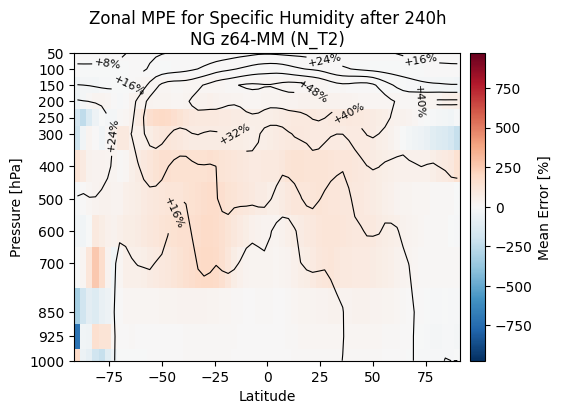

In [8]:


models=[0,1,2,3,5]
eval_past=[0,1]
eval_vars=[0,1,2]
levels = []
add_save_info=''
# Temp, remove later
models=[0,1,2,3]
eval_vars=[2]
# Temp, remove later


use_custom_levels = not len(levels) == 0
if use_custom_levels:
    add_save_info = '_reduced_levels'
num_models=len(models)
plot_error=True
plot_error_with_extrapolation=False
plot_error_future_past_difference=True
plot_scatterplot=True
plot_scatterplot_future_hist_difference=True

ng_train = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/copied/global_nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative/fields.zarr').astype(np.float32)
ng_train = ng_train.sel(time=slice("1990", "2015"))

model_short_names = ['NG z64-MM','NG z128-MM','NG z256-MM','NG z64-H', 'Persistence', 'Era5 z64-MM']

for key in eval_vars:
    if key == 0:
        short_name='Geopotential'
        use_percentage=False
    if key == 1:
        short_name='Temperature'
        use_percentage=False
    elif key==2:
        short_name='Specific Humidity'
        use_percentage=True

    display_name, unit, variable, plevel, _ = plot.KEY_VARIABLES[key]
    
    print('')
    print('#'*20)
    print(f'Current variable: {display_name}')
    print('#'*20)
    mean_past_values = {}
    for plevel in [int(x) for x in ng_train.level.values]:
        mean_past_value = get_mean_of_var(key, plevel=plevel)
        mean_past_values[int(plevel)] = mean_past_value
    max_past_values = {}
    for plevel in [int(x) for x in ng_train.level.values]:
        max_past_value = get_min_max_of_var(key, plevel=plevel)
        max_past_values[int(plevel)] = max_past_value
    
    all_vals = [[],[]]
    all_shift_vals = [[],[]]
    all_extrapolate_vals = [[],[]]
    all_diffs=[]
    max_val=0
    min_val=0
    
    for model_idx in models:
    
        
        selected_model_past=plot.PAST_MODELS_NG_era5[model_idx]
        selected_model_future=plot.FUTURE_MODELS_NG_era5[model_idx]
        
        current_model_resolution = selected_model_past['id']
        print(f'Evaluating model: {selected_model_past["model_name"]}')
        
        base_save_folder_past = selected_model_past['plot_folder']
        base_save_folder_future = selected_model_future['plot_folder']
        
        ng_past_forecasts = xr.open_zarr(selected_model_past['forecasts'], decode_timedelta=True).astype(np.float32)
        ng_future_forecasts = xr.open_zarr(selected_model_future['forecasts'], decode_timedelta=True).astype(np.float32)
        
        ng_past_truth = xr.open_zarr(selected_model_past['ground_truth']).astype(np.float32)
        ng_future_truth = xr.open_zarr(selected_model_future['ground_truth']).astype(np.float32)
        
        for past in eval_past:
            
            print(f'Evaluating {"past" if past else "future"}')
            steps = [10 * 24]
            hours_into_future=steps[0]
        
            # Load truth & forecast datasets
            ds_test_truth, ds_test_forecast = (
                get_datasets_after(ng_past_truth, ng_past_forecasts, hours_into_future)
                if past
                else get_datasets_after(ng_future_truth, ng_future_forecasts, hours_into_future)
            )
            
            truth = ds_test_truth[variable]
            forecast = ds_test_forecast[variable]
            # --- Process each level separately ---
            zonal_means = []
            zonal_shifts = []
            extrap_means = []

            if not use_custom_levels:
                levels = truth.level.values
            for plevel in [int(x) for x in levels]:
                
                truth_level = truth.sel(level=plevel)
                forecast_level = forecast.sel(level=plevel)
            
                 # Compute % difference safely
                if use_percentage:
                    data_level = (forecast_level - truth_level) / (truth_level) * 100
                    data_shift = (truth_level.mean(dim='time') - mean_past_values[plevel]) / (np.abs(mean_past_values[plevel])) * 100
                    eps = 1e-6  # or physically motivated threshold
                    data_level = data_level.where(truth_level > eps)
                else:
                    data_level = forecast_level - truth_level # Compute absolute difference
                    data_shift = truth_level.mean(dim='time') - mean_past_values[plevel]
            
                # Compute zonal mean (longitude)
                if "longitude" in data_level.dims:
                    zonal_mean = data_level.mean(dim="longitude")
                    zonal_shift = data_shift.mean(dim="longitude")
                else:
                    zonal_mean = data_level
                    zonal_shift = data_shift
            
                # Average over time if present
                if "time" in zonal_mean.dims:
                    zonal_mean = zonal_mean.mean(dim="time")
            
                # Store result with level coordinate
                zonal_means.append(zonal_mean.expand_dims("level"))
                zonal_shifts.append(zonal_shift.expand_dims("level"))

                threshold = max_past_values[plevel]   # shape (lat,)
                threshold_bc = threshold.broadcast_like(truth_level)
                
                # compute extrap lat-by-lat
                extrap_level = ((truth_level > threshold_bc)
                                .mean(dim=("longitude","time")) * 100)
                extrap_means.append(extrap_level.expand_dims("level"))
            
            print(f"Processed all pressure levels")
            
            # --- Combine all processed levels ---
            zonal_mean_all = xr.concat(zonal_means, dim="level")
            zonal_shift_all = xr.concat(zonal_shifts, dim="level")
            zonal_extrapolate_all = xr.concat(extrap_means, dim="level")
            
            # --- Extract coordinates and data ---
            lat = zonal_mean_all["latitude"].values
            plev = levels
            vals = zonal_mean_all.values
            shift_vals = zonal_shift_all.values
            extrapolate_vals = zonal_extrapolate_all.values
            if np.nanmax(vals) > max_val:
                max_val = np.nanmax(vals)
            if np.nanmin(vals) < min_val:
                min_val = np.nanmin(vals)

            all_vals[past].append(vals)
            all_shift_vals[past].append(shift_vals)
            all_extrapolate_vals[past].append(extrapolate_vals)
    if plot_error_future_past_difference:
        for i, model_idx in enumerate(models):
            diff = all_vals[0][i]-all_vals[1][i]
            all_diffs.append(max(abs(np.nanmax(diff)),abs(np.nanmin(diff))))
    
    for i, model_idx in enumerate(models):
        
        selected_model_past=plot.PAST_MODELS_NG_era5[model_idx]
        selected_model_future=plot.FUTURE_MODELS_NG_era5[model_idx]
        current_model_resolution = selected_model_past['id']
        print(f'Evaluating model: {selected_model_past["model_name"]}')
        current_model_short_name = model_short_names[model_idx]
        
        # base_save_folder_past = selected_model_past['plot_folder']
        # base_save_folder_future = selected_model_future['plot_folder']
        base_save_folder_past = '/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/humidity_eps/'
        base_save_folder_future = '/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/humidity_eps/'

        
        for past in eval_past:
            
            save_to=base_save_folder_past
            create_folder_if_not_exists(save_to)
            save_name=f'{current_model_short_name}_{"hist" if past else "future"}_{variable}_with_average_shift'
            print(save_to)
            
            vals = all_vals[past][i]
            vals_stretched = np.repeat(vals, 2, axis=0)
            shift_vals = all_shift_vals[past][i]
            extrapolate_vals = all_extrapolate_vals[past][i]
            plev_stretched = np.repeat(plev, 2)
            shift_vals_stretched = np.repeat(shift_vals, 2, axis=0)
            extrapolate_vals_stretched = np.repeat(extrapolate_vals, 2, axis=0)
    
            if plot_error:
                # --- Plot ---
                fig, ax = plt.subplots(figsize=(6,4))
                bounds_val = max(abs(min_val), abs(max_val))
                cf = ax.pcolormesh(
                    lat,
                    plev_stretched,
                    vals_stretched,
                    cmap="RdBu_r",
                    shading="auto",
                    vmin=-bounds_val,
                    vmax=bounds_val,
                )
                CS = ax.contour(
                    lat,
                    plev_stretched,
                    shift_vals_stretched,
                    colors="black",
                    linewidths=0.8
                )
                ax.clabel(CS, inline=True, fmt="%+d%%" if use_percentage else f"%+.1f{unit}", fontsize=8)
                ax.invert_yaxis()
                ax.set_xlabel("Latitude")
                ax.set_yticks(plev)
                ax.set_ylabel("Pressure [hPa]")
                ax.set_title(f"Zonal {'MPE' if use_percentage else 'ME'} for {short_name} after {hours_into_future}h\n"+\
                             f"{current_model_short_name} ({'N_T1' if past else 'N_T2'})")
                
                cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
                cbar.set_label(f"Mean Error [{'%' if use_percentage else unit}]")
                plt.savefig(save_to+save_name+add_save_info+'.pdf', bbox_inches="tight", dpi=600)
                plt.savefig(save_to+save_name+add_save_info+'.png', bbox_inches="tight", dpi=600)
    
            if not past:
                if plot_error_with_extrapolation:
                    save_name=f'{variable}_with_extrapolation.png'
                    fig, ax = plt.subplots(figsize=(6,4))
                    bounds_val = max(abs(min_val), abs(max_val))
                    
                    cf = ax.pcolormesh(
                        lat,
                        plev_stretched,
                        vals_stretched,
                        cmap="RdBu_r",
                        shading="auto",
                        vmin=-bounds_val,
                        vmax=bounds_val,
                    )
                    CS = ax.contour(
                        lat,
                        plev_stretched,
                        extrapolate_vals_stretched,
                        colors="black",
                        linewidths=0.8
                    )
                    ax.clabel(CS, inline=True, fmt="%d%%", fontsize=8)
                    ax.invert_yaxis()
                    ax.set_xlabel("Latitude")
                    ax.set_yticks(plev)
                    ax.set_ylabel("Pressure [hPa]")
                    ax.set_title(f"{short_name} after {hours_into_future}h: Zonal {'MPE' if use_percentage else 'ME'} ({'%' if use_percentage else unit}) ({'2016-2019' if past else '2046-2049'})")
                    
                    cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
                    cbar.set_label(f"Error [{'%' if use_percentage else unit}]")
                    plt.savefig(save_to+save_name, bbox_inches="tight", dpi=600)
                    plt.close()
                
                # diff = all_vals[0][i]-all_vals[1][i]
                # max(abs(np.nanmax(diff)),abs(np.nanmin(diff)))
                if plot_error_future_past_difference:
                    vals_stretched_past = np.repeat(all_vals[1][i], 2, axis=0)
                    vals_stretched_future = np.repeat(all_vals[0][i], 2, axis=0)
                    shift_vals_stretched_past = np.repeat(all_shift_vals[1][i], 2, axis=0)
                    shift_vals_stretched_future = np.repeat(all_shift_vals[0][i], 2, axis=0)
        
                    save_name=f'{current_model_short_name}_{variable}_future_hist_difference'
                
                    # --- Plot ---
                    fig, ax = plt.subplots(figsize=(6,4))
                    bounds_val = max(abs(min_val), abs(max_val))
                    cf = ax.pcolormesh(
                        lat,
                        plev_stretched,
                        vals_stretched_future-vals_stretched_past,
                        cmap="RdBu_r",
                        shading="auto",
                        vmin=-max(all_diffs),
                        vmax=max(all_diffs)
                    )
                    CS = ax.contour(
                        lat,
                        plev_stretched,
                        shift_vals_stretched_future-shift_vals_stretched_past,
                        colors="black",
                        linewidths=0.8
                    )
                    ax.clabel(CS, inline=True, fmt="%+d%%" if use_percentage else "%+.1f", fontsize=8)
                    ax.invert_yaxis()
                    ax.set_xlabel("Latitude")
                    ax.set_yticks(plev)
                    ax.set_ylabel("Pressure [hPa]")
                    ax.set_title(f"{current_model_short_name}, {short_name} after {hours_into_future}h\n" + \
                        f"Zonal {'MPE' if use_percentage else 'ME'} N_T2 - Zonal {'MPE' if use_percentage else 'ME'} N_T1")
                    
                    cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
                    cbar.set_label(f"Zonal {'MPE' if use_percentage else 'ME'} N_T2 - Zonal {'MPE' if use_percentage else 'ME'} N_T1 [{'%' if use_percentage else unit}]")
                    plt.savefig(save_to+'png/'+save_name+'.png', bbox_inches="tight", dpi=600)
                    plt.savefig(save_to+save_name+'.pdf', bbox_inches="tight", dpi=600)
                    plt.close()
    
    
                if plot_scatterplot:
                    save_name = f'{current_model_short_name}_{variable}_future_scatter'
                    
                    shift_vals_flat = shift_vals.flatten()
                    error_vals = vals.flatten()
                    
                    # Remove NaNs that may occur from masked areas
                    mask = np.isfinite(shift_vals_flat) & np.isfinite(error_vals)
                    shift_vals_flat = shift_vals_flat[mask]
                    error_vals = error_vals[mask]
    
                    levels = np.repeat(zonal_mean_all.level.values, zonal_mean_all.latitude.size)
                    levels = levels[mask]
                    
                    plt.figure(figsize=(7, 4.66))
                    sc = plt.scatter(shift_vals_flat, error_vals, c=levels, s=10, cmap='viridis', alpha=0.6)
                    plt.colorbar(sc, label="Pressure Level (hPa)")
                    
                    
                    plt.axvline(0, color='gray', linewidth=1)
                    plt.axhline(0, color='gray', linewidth=1)
                    
                    plt.xlabel(f"{'Relative' if use_percentage else 'Absolute'} Distribution Shift [{'%' if use_percentage else unit}]")
                    plt.ylabel(f"Zonal {'MPE [%]' if use_percentage else f'ME [{unit}]'}")
                    plt.title(f"{current_model_resolution}, {short_name} after {hours_into_future}h ({'2016-2019' if past else '2046-2049'}):\nZonal Model Error per Distribution Shift")

                    plt.xlabel("Relative Distribution Shift (N_T2 Mean - N_TR Mean) / N_TR Mean" if use_percentage else "Distribution Shift (N_T2 Mean - N_TR Mean)")
                    plt.ylabel("Mean Percentage Error (FC-GT)/GT" if use_percentage else "Mean Error (FC-GT)")
                    plt.title(f"Zonal Mean Relationship: Distribution Shift - Model Error\n{current_model_short_name} N_T2")
                    
                    plt.grid(True, linestyle='--', alpha=0.3)
                    plt.tight_layout()
                    plt.savefig(save_to+'png/'+save_name+'.png', bbox_inches="tight", dpi=600)
                    plt.savefig(save_to+save_name+'.pdf', bbox_inches="tight", dpi=600)
                    plt.close()




                    # save_name = f'{current_model_short_name}_{variable}_future_scatter_per_level'
                    # plt.figure(figsize=(7, 4.66))
                    # sc = plt.scatter(shift_vals_flat, error_vals, c=levels, s=10,
                    #                  cmap=cmap, norm=norm, alpha=0.6)
                    
                    # # Discrete colorbar
                    # cbar = plt.colorbar(sc, boundaries=boundaries, ticks=unique_levels)
                    # cbar.set_label("Pressure Level (hPa)")
                    # cbar.ax.set_yticklabels([f"{lvl:.0f}" for lvl in unique_levels])
                    
                    
                    # target_level = 200  # or whatever value corresponds in your data
                    
                    # # Boolean mask selecting 200 hPa AND negative shift
                    # mask_neg = (levels == target_level) & (shift_vals_flat < 0)
                    
                    # x_neg = shift_vals_flat[mask_neg]
                    # y_neg = error_vals[mask_neg]
                    
                    # if len(x_neg) >= 2:
                    #     slope, intercept, r_value, p_value, std_err = linregress(x_neg, y_neg)
                    
                    #     # Create a small x-range for plotting the negative-shift regression line
                    #     x_vals_neg = np.linspace(x_neg.min(), x_neg.max(), 200)
                    
                    #     # Use a dashed line but same color as 200 hPa for consistency
                    #     plt.plot(
                    #         x_vals_neg,
                    #         intercept + slope * x_vals_neg,
                    #         linewidth=2,
                    #         linestyle='--',
                    #         color=cmap(norm(target_level)),
                    #         label=f"{target_level} hPa (shift<0, r = {r_value:.2f})"
                    #     )
                    # mask_pos = (levels == target_level) & (shift_vals_flat > 0)
                    
                    # x_pos = shift_vals_flat[mask_pos]
                    # y_pos = error_vals[mask_pos]
                    
                    # if len(x_pos) >= 2:
                    #     slope, intercept, r_value, p_value, std_err = linregress(x_pos, y_pos)
                    
                    #     # Create a small x-range for plotting the negative-shift regression line
                    #     x_vals_pos = np.linspace(x_pos.min(), x_pos.max(), 200)
                    
                    #     # Use a dashed line but same color as 200 hPa for consistency
                    #     plt.plot(
                    #         x_vals_pos,
                    #         intercept + slope * x_vals_pos,
                    #         linewidth=2,
                    #         color=cmap(norm(target_level)),
                    #         label=f"{int(target_level)} hPa (shift>0, r = {r_value:.2f})"if len(x_neg) >= 2 else f"{int(target_level)} hPa (r = {r_value:.2f})"
                    #     )
                    # # Regression line
                    # for lvl in unique_levels[1:]:
                    #     # Select points belonging to this pressure level
                    #     mask_lvl = levels == lvl
                    #     x = shift_vals_flat[mask_lvl]
                    #     y = error_vals[mask_lvl]
                    
                    #     # Skip levels with too few points
                    #     if len(x) < 2:
                    #         continue
                    
                    #     # Linear regression for this level
                    #     slope, intercept, r_value, p_value, std_err = linregress(x, y)
                    
                    #     # X-range for plotting the line for this level
                    #     x_vals = np.linspace(x.min(), x.max(), 200)
                    
                    #     # Plot line in the same discrete color used for this level
                    #     plt.plot(
                    #         x_vals,
                    #         intercept + slope * x_vals,
                    #         linewidth=2,
                    #         color=cmap(norm(lvl)),   # ensures color matches scatter & colorbar
                    #         label=f"{int(lvl)} hPa (r = {r_value:.2f})"
                    #     )
                    # plt.axvline(0, color='gray', linewidth=1)
                    # plt.axhline(0, color='gray', linewidth=1)
                    # plt.xlabel("Relative Distribution Shift (T2 Mean - TR Mean) / TR Mean" if use_percentage else "Distribution Shift (T2 Mean - TR Mean)")
                    # plt.ylabel("Mean Percentage Error (FC-GT)/GT" if use_percentage else "Mean Error (FC-GT)")
                    # plt.title(f"Zonal Mean Relationship: Distribution Shift - Model Error\n{current_model_short_name} U_T2")
                    # plt.grid(True, linestyle='--', alpha=0.3)
                    # plt.legend(framealpha=0.6)
                    # plt.tight_layout()
                    # plt.savefig(save_to+'png/'+save_name+'.png', bbox_inches="tight", dpi=600)
                    # plt.savefig(save_to+save_name+'.pdf', bbox_inches="tight", dpi=600)
                    # plt.show()

                    
                if plot_scatterplot_future_hist_difference:
                    save_name = f'{current_model_short_name}_{variable}_future_scatter_difference'
                    shift_difference = all_shift_vals[0][i]-all_shift_vals[1][i]
                    error_difference = all_vals[0][i]-all_vals[1][i]

                    
                    shift_vals_flat = shift_difference.flatten()
                    error_vals = error_difference.flatten()
                    
                    levels = np.repeat(zonal_mean_all.level.values, zonal_mean_all.latitude.size)
                    levels = levels[mask]
                    
                    plt.figure(figsize=(7, 4.66))
                    sc = plt.scatter(shift_vals_flat, error_vals, c=levels, s=10, cmap='viridis', alpha=0.6)
                    plt.colorbar(sc, label="Pressure Level (hPa)")
                    
                    
                    plt.axvline(0, color='gray', linewidth=1)
                    plt.axhline(0, color='gray', linewidth=1)
                    
                    plt.xlabel(f"{'Relative' if use_percentage else 'Absolute'} Distribution Shift [{'%' if use_percentage else unit}]")
                    plt.ylabel(f"Zonal {'MPE [%]' if use_percentage else f'ME [{unit}]'}")

                    plt.xlabel("Relative Distribution Shift (N_T2 Mean - N_T1 Mean) / N_T1 Mean" if use_percentage else "Distribution Shift (N_T2 Mean - N_T1 Mean)")
                    plt.ylabel(f"Zonal {'MPE' if use_percentage else 'ME'} N_T2 - Zonal {'MPE' if use_percentage else 'ME'} N_T1")
                    plt.title(f"Zonal Mean Relationship {current_model_short_name}\nDistribution Shift - Model Error Difference")
                    
                    plt.grid(True, linestyle='--', alpha=0.3)
                    plt.tight_layout()
                    plt.savefig(save_to+'png/'+save_name+'.png', bbox_inches="tight", dpi=600)
                    plt.savefig(save_to+save_name+'.pdf', bbox_inches="tight", dpi=600)
                    plt.close()

<xarray.DataArray 'specific_humidity' (level: 13, latitude: 64)> Size: 3kB
dask.array<mean_agg-aggregate, shape=(13, 64), dtype=float32, chunksize=(13, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
  * level     (level) int64 104B 50 100 150 200 250 300 ... 600 700 850 925 1000


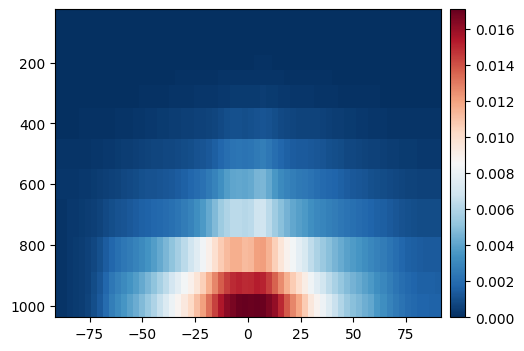

In [19]:
data = truth.mean(dim='time').mean(dim='longitude')
print(data)
fig, ax = plt.subplots(figsize=(6,4))
bounds_val = max(abs(min_val), abs(max_val))
cf = ax.pcolormesh(
    lat,
    plev,
    data,
    cmap="RdBu_r",
    shading="auto",
    vmin=0
)
ax.invert_yaxis()
cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
fig.show()

Evaluating model: NextGEMS z64 Multi-Mesh
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/humidity_eps/
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/humidity_eps/
Evaluating model: NextGEMS z128 Multi-Mesh
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/humidity_eps/
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/humidity_eps/
Evaluating model: NextGEMS z256 Multi-Mesh
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/humidity_eps/
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/humidity_eps/
Evaluating model: NextGEMS z64 Hierarchical
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/humidity_eps/
/h

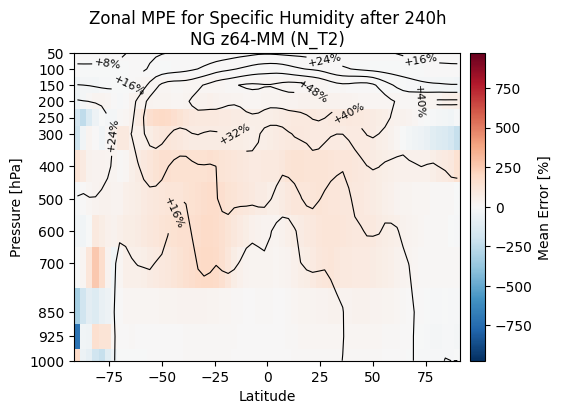

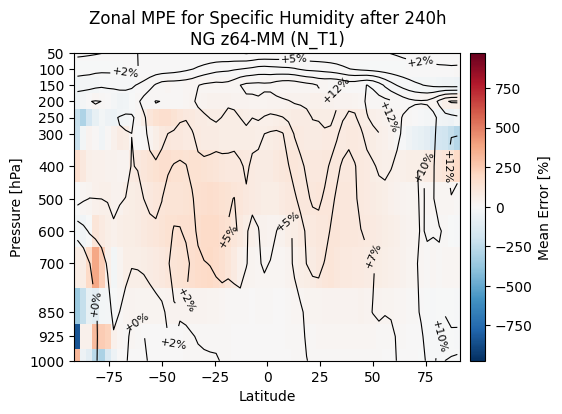

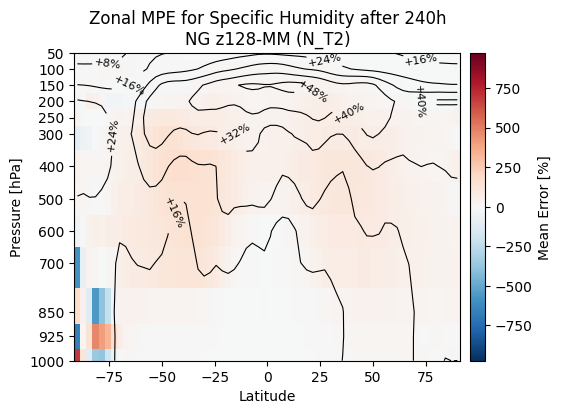

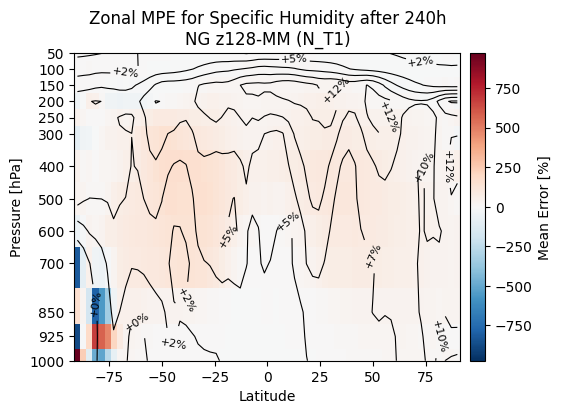

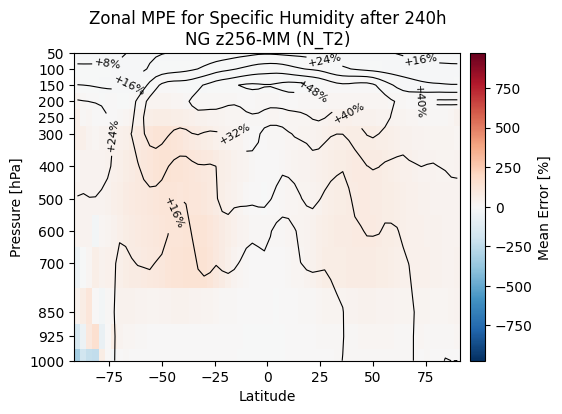

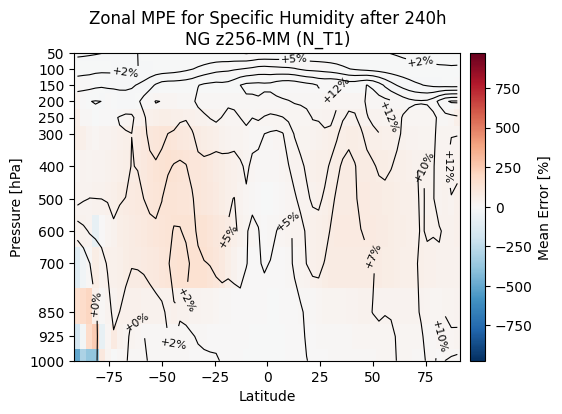

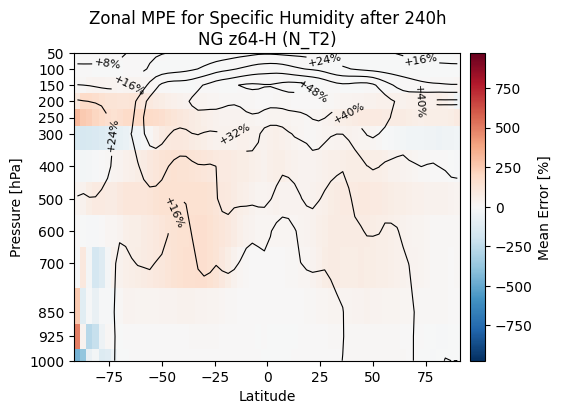

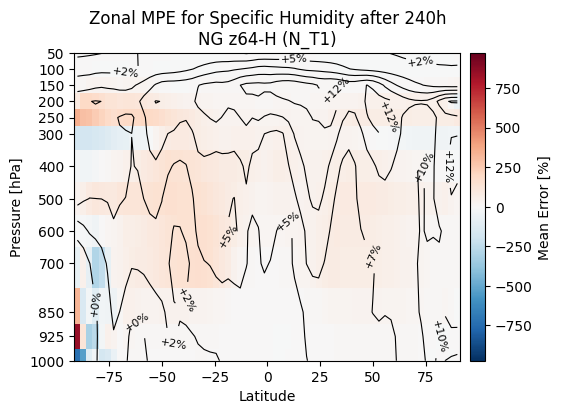

In [10]:
add_save_info=''
for i, model_idx in enumerate(models):
        
    selected_model_past=plot.PAST_MODELS_NG_era5[model_idx]
    selected_model_future=plot.FUTURE_MODELS_NG_era5[model_idx]
    current_model_resolution = selected_model_past['id']
    print(f'Evaluating model: {selected_model_past["model_name"]}')
    current_model_short_name = model_short_names[model_idx]
    
    # base_save_folder_past = selected_model_past['plot_folder']
    # base_save_folder_future = selected_model_future['plot_folder']
    base_save_folder_past = '/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/humidity_eps/'
    base_save_folder_future = '/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/humidity_eps/'

    
    for past in eval_past:
        
        save_to=base_save_folder_past
        create_folder_if_not_exists(save_to)
        save_name=f'{current_model_short_name}_{"hist" if past else "future"}_{variable}_with_average_shift'
        print(save_to)
        
        vals = all_vals[past][i]
        vals_stretched = np.repeat(vals, 2, axis=0)
        shift_vals = all_shift_vals[past][i]
        extrapolate_vals = all_extrapolate_vals[past][i]
        plev_stretched = np.repeat(plev, 2)
        shift_vals_stretched = np.repeat(shift_vals, 2, axis=0)
        extrapolate_vals_stretched = np.repeat(extrapolate_vals, 2, axis=0)

        if plot_error:
            # --- Plot ---
            fig, ax = plt.subplots(figsize=(6,4))
            bounds_val = max(abs(min_val), abs(max_val))
            cf = ax.pcolormesh(
                lat,
                plev_stretched,
                vals_stretched,
                cmap="RdBu_r",
                shading="auto",
                vmin=-bounds_val,
                vmax=bounds_val,
            )
            CS = ax.contour(
                lat,
                plev_stretched,
                shift_vals_stretched,
                colors="black",
                linewidths=0.8
            )
            ax.clabel(CS, inline=True, fmt="%+d%%" if use_percentage else f"%+.1f{unit}", fontsize=8)
            ax.invert_yaxis()
            ax.set_xlabel("Latitude")
            ax.set_yticks(plev)
            ax.set_ylabel("Pressure [hPa]")
            ax.set_title(f"Zonal {'MPE' if use_percentage else 'ME'} for {short_name} after {hours_into_future}h\n"+\
                         f"{current_model_short_name} ({'N_T1' if past else 'N_T2'})")
            
            cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
            cbar.set_label(f"Mean Error [{'%' if use_percentage else unit}]")
            plt.savefig(save_to+save_name+add_save_info+'.pdf', bbox_inches="tight", dpi=600)
            plt.savefig(save_to+save_name+add_save_info+'.png', bbox_inches="tight", dpi=600)

        if not past:
            if plot_error_with_extrapolation:
                save_name=f'{variable}_with_extrapolation.png'
                fig, ax = plt.subplots(figsize=(6,4))
                bounds_val = max(abs(min_val), abs(max_val))
                
                cf = ax.pcolormesh(
                    lat,
                    plev_stretched,
                    vals_stretched,
                    cmap="RdBu_r",
                    shading="auto",
                    vmin=-bounds_val,
                    vmax=bounds_val,
                )
                CS = ax.contour(
                    lat,
                    plev_stretched,
                    extrapolate_vals_stretched,
                    colors="black",
                    linewidths=0.8
                )
                ax.clabel(CS, inline=True, fmt="%d%%", fontsize=8)
                ax.invert_yaxis()
                ax.set_xlabel("Latitude")
                ax.set_yticks(plev)
                ax.set_ylabel("Pressure [hPa]")
                ax.set_title(f"{short_name} after {hours_into_future}h: Zonal {'MPE' if use_percentage else 'ME'} ({'%' if use_percentage else unit}) ({'2016-2019' if past else '2046-2049'})")
                
                cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
                cbar.set_label(f"Error [{'%' if use_percentage else unit}]")
                plt.savefig(save_to+save_name, bbox_inches="tight", dpi=600)
                plt.close()
            
            # diff = all_vals[0][i]-all_vals[1][i]
            # max(abs(np.nanmax(diff)),abs(np.nanmin(diff)))
            if plot_error_future_past_difference:
                vals_stretched_past = np.repeat(all_vals[1][i], 2, axis=0)
                vals_stretched_future = np.repeat(all_vals[0][i], 2, axis=0)
                shift_vals_stretched_past = np.repeat(all_shift_vals[1][i], 2, axis=0)
                shift_vals_stretched_future = np.repeat(all_shift_vals[0][i], 2, axis=0)
    
                save_name=f'{current_model_short_name}_{variable}_future_hist_difference'
            
                # --- Plot ---
                fig, ax = plt.subplots(figsize=(6,4))
                bounds_val = max(abs(min_val), abs(max_val))
                cf = ax.pcolormesh(
                    lat,
                    plev_stretched,
                    vals_stretched_future-vals_stretched_past,
                    cmap="RdBu_r",
                    shading="auto",
                    vmin=-max(all_diffs),
                    vmax=max(all_diffs)
                )
                CS = ax.contour(
                    lat,
                    plev_stretched,
                    shift_vals_stretched_future-shift_vals_stretched_past,
                    colors="black",
                    linewidths=0.8
                )
                ax.clabel(CS, inline=True, fmt="%+d%%" if use_percentage else "%+.1f", fontsize=8)
                ax.invert_yaxis()
                ax.set_xlabel("Latitude")
                ax.set_yticks(plev)
                ax.set_ylabel("Pressure [hPa]")
                ax.set_title(f"{current_model_short_name}, {short_name} after {hours_into_future}h\n" + \
                    f"Zonal {'MPE' if use_percentage else 'ME'} N_T2 - Zonal {'MPE' if use_percentage else 'ME'} N_T1")
                
                cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
                cbar.set_label(f"Zonal {'MPE' if use_percentage else 'ME'} N_T2 - Zonal {'MPE' if use_percentage else 'ME'} N_T1 [{'%' if use_percentage else unit}]")
                plt.savefig(save_to+'png/'+save_name+'.png', bbox_inches="tight", dpi=600)
                plt.savefig(save_to+save_name+'.pdf', bbox_inches="tight", dpi=600)
                plt.close()


            if plot_scatterplot:
                save_name = f'{current_model_short_name}_{variable}_future_scatter'
                
                shift_vals_flat = shift_vals.flatten()
                error_vals = vals.flatten()
                
                # Remove NaNs that may occur from masked areas
                mask = np.isfinite(shift_vals_flat) & np.isfinite(error_vals)
                shift_vals_flat = shift_vals_flat[mask]
                error_vals = error_vals[mask]

                levels = np.repeat(zonal_mean_all.level.values, zonal_mean_all.latitude.size)
                levels = levels[mask]
                
                plt.figure(figsize=(7, 4.66))
                sc = plt.scatter(shift_vals_flat, error_vals, c=levels, s=10, cmap='viridis', alpha=0.6)
                plt.colorbar(sc, label="Pressure Level (hPa)")
                
                
                plt.axvline(0, color='gray', linewidth=1)
                plt.axhline(0, color='gray', linewidth=1)
                
                plt.xlabel(f"{'Relative' if use_percentage else 'Absolute'} Distribution Shift [{'%' if use_percentage else unit}]")
                plt.ylabel(f"Zonal {'MPE [%]' if use_percentage else f'ME [{unit}]'}")
                plt.title(f"{current_model_resolution}, {short_name} after {hours_into_future}h ({'2016-2019' if past else '2046-2049'}):\nZonal Model Error per Distribution Shift")

                plt.xlabel("Relative Distribution Shift (N_T2 Mean - N_TR Mean) / N_TR Mean" if use_percentage else "Distribution Shift (N_T2 Mean - N_TR Mean)")
                plt.ylabel("Mean Percentage Error (FC-GT)/GT" if use_percentage else "Mean Error (FC-GT)")
                plt.title(f"Zonal Mean Relationship: Distribution Shift - Model Error\n{current_model_short_name} N_T2")
                
                plt.grid(True, linestyle='--', alpha=0.3)
                plt.tight_layout()
                plt.savefig(save_to+'png/'+save_name+'.png', bbox_inches="tight", dpi=600)
                plt.savefig(save_to+save_name+'.pdf', bbox_inches="tight", dpi=600)
                plt.close()




                # save_name = f'{current_model_short_name}_{variable}_future_scatter_per_level'
                # plt.figure(figsize=(7, 4.66))
                # sc = plt.scatter(shift_vals_flat, error_vals, c=levels, s=10,
                #                  cmap=cmap, norm=norm, alpha=0.6)
                
                # # Discrete colorbar
                # cbar = plt.colorbar(sc, boundaries=boundaries, ticks=unique_levels)
                # cbar.set_label("Pressure Level (hPa)")
                # cbar.ax.set_yticklabels([f"{lvl:.0f}" for lvl in unique_levels])
                
                
                # target_level = 200  # or whatever value corresponds in your data
                
                # # Boolean mask selecting 200 hPa AND negative shift
                # mask_neg = (levels == target_level) & (shift_vals_flat < 0)
                
                # x_neg = shift_vals_flat[mask_neg]
                # y_neg = error_vals[mask_neg]
                
                # if len(x_neg) >= 2:
                #     slope, intercept, r_value, p_value, std_err = linregress(x_neg, y_neg)
                
                #     # Create a small x-range for plotting the negative-shift regression line
                #     x_vals_neg = np.linspace(x_neg.min(), x_neg.max(), 200)
                
                #     # Use a dashed line but same color as 200 hPa for consistency
                #     plt.plot(
                #         x_vals_neg,
                #         intercept + slope * x_vals_neg,
                #         linewidth=2,
                #         linestyle='--',
                #         color=cmap(norm(target_level)),
                #         label=f"{target_level} hPa (shift<0, r = {r_value:.2f})"
                #     )
                # mask_pos = (levels == target_level) & (shift_vals_flat > 0)
                
                # x_pos = shift_vals_flat[mask_pos]
                # y_pos = error_vals[mask_pos]
                
                # if len(x_pos) >= 2:
                #     slope, intercept, r_value, p_value, std_err = linregress(x_pos, y_pos)
                
                #     # Create a small x-range for plotting the negative-shift regression line
                #     x_vals_pos = np.linspace(x_pos.min(), x_pos.max(), 200)
                
                #     # Use a dashed line but same color as 200 hPa for consistency
                #     plt.plot(
                #         x_vals_pos,
                #         intercept + slope * x_vals_pos,
                #         linewidth=2,
                #         color=cmap(norm(target_level)),
                #         label=f"{int(target_level)} hPa (shift>0, r = {r_value:.2f})"if len(x_neg) >= 2 else f"{int(target_level)} hPa (r = {r_value:.2f})"
                #     )
                # # Regression line
                # for lvl in unique_levels[1:]:
                #     # Select points belonging to this pressure level
                #     mask_lvl = levels == lvl
                #     x = shift_vals_flat[mask_lvl]
                #     y = error_vals[mask_lvl]
                
                #     # Skip levels with too few points
                #     if len(x) < 2:
                #         continue
                
                #     # Linear regression for this level
                #     slope, intercept, r_value, p_value, std_err = linregress(x, y)
                
                #     # X-range for plotting the line for this level
                #     x_vals = np.linspace(x.min(), x.max(), 200)
                
                #     # Plot line in the same discrete color used for this level
                #     plt.plot(
                #         x_vals,
                #         intercept + slope * x_vals,
                #         linewidth=2,
                #         color=cmap(norm(lvl)),   # ensures color matches scatter & colorbar
                #         label=f"{int(lvl)} hPa (r = {r_value:.2f})"
                #     )
                # plt.axvline(0, color='gray', linewidth=1)
                # plt.axhline(0, color='gray', linewidth=1)
                # plt.xlabel("Relative Distribution Shift (T2 Mean - TR Mean) / TR Mean" if use_percentage else "Distribution Shift (T2 Mean - TR Mean)")
                # plt.ylabel("Mean Percentage Error (FC-GT)/GT" if use_percentage else "Mean Error (FC-GT)")
                # plt.title(f"Zonal Mean Relationship: Distribution Shift - Model Error\n{current_model_short_name} U_T2")
                # plt.grid(True, linestyle='--', alpha=0.3)
                # plt.legend(framealpha=0.6)
                # plt.tight_layout()
                # plt.savefig(save_to+'png/'+save_name+'.png', bbox_inches="tight", dpi=600)
                # plt.savefig(save_to+save_name+'.pdf', bbox_inches="tight", dpi=600)
                # plt.show()

                
            if plot_scatterplot_future_hist_difference:
                save_name = f'{current_model_short_name}_{variable}_future_scatter_difference'
                shift_difference = all_shift_vals[0][i]-all_shift_vals[1][i]
                error_difference = all_vals[0][i]-all_vals[1][i]

                
                shift_vals_flat = shift_difference.flatten()
                error_vals = error_difference.flatten()
                
                levels = np.repeat(zonal_mean_all.level.values, zonal_mean_all.latitude.size)
                levels = levels[mask]
                
                plt.figure(figsize=(7, 4.66))
                sc = plt.scatter(shift_vals_flat, error_vals, c=levels, s=10, cmap='viridis', alpha=0.6)
                plt.colorbar(sc, label="Pressure Level (hPa)")
                
                
                plt.axvline(0, color='gray', linewidth=1)
                plt.axhline(0, color='gray', linewidth=1)
                
                plt.xlabel(f"{'Relative' if use_percentage else 'Absolute'} Distribution Shift [{'%' if use_percentage else unit}]")
                plt.ylabel(f"Zonal {'MPE [%]' if use_percentage else f'ME [{unit}]'}")

                plt.xlabel("Relative Distribution Shift (N_T2 Mean - N_T1 Mean) / N_T1 Mean" if use_percentage else "Distribution Shift (N_T2 Mean - N_T1 Mean)")
                plt.ylabel(f"Zonal {'MPE' if use_percentage else 'ME'} N_T2 - Zonal {'MPE' if use_percentage else 'ME'} N_T1")
                plt.title(f"Zonal Mean Relationship {current_model_short_name}\nDistribution Shift - Model Error Difference")
                
                plt.grid(True, linestyle='--', alpha=0.3)
                plt.tight_layout()
                plt.savefig(save_to+'png/'+save_name+'.png', bbox_inches="tight", dpi=600)
                plt.savefig(save_to+save_name+'.pdf', bbox_inches="tight", dpi=600)
                plt.close()

In [17]:
plot_error=False
plot_error_with_extrapolation=False
plot_error_future_past_difference=True
plot_scatterplot=False
plot_scatterplot_future_hist_difference=False
for i, model_idx in enumerate(models):
        
    selected_model_past=plot.PAST_MODELS_NG_era5[model_idx]
    selected_model_future=plot.FUTURE_MODELS_NG_era5[model_idx]
    current_model_resolution = selected_model_past['id']
    print(f'Evaluating model: {selected_model_past["model_name"]}')
    current_model_short_name = model_short_names[model_idx]
    
    # base_save_folder_past = selected_model_past['plot_folder']
    # base_save_folder_future = selected_model_future['plot_folder']
    base_save_folder_past = '/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/'
    base_save_folder_future = '/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/'

    
    for past in eval_past:
        
        save_to=base_save_folder_past
        create_folder_if_not_exists(save_to)
        save_name=f'{current_model_short_name}_{"hist" if past else "future"}_{variable}_with_average_shift.png'
        print(save_to)
        
        vals = all_vals[past][i]
        vals_stretched = np.repeat(vals, 2, axis=0)
        shift_vals = all_shift_vals[past][i]
        extrapolate_vals = all_extrapolate_vals[past][i]
        plev_stretched = np.repeat(plev, 2)
        shift_vals_stretched = np.repeat(shift_vals, 2, axis=0)
        extrapolate_vals_stretched = np.repeat(extrapolate_vals, 2, axis=0)

        if plot_error:
            # --- Plot ---
            fig, ax = plt.subplots(figsize=(6,4))
            bounds_val = max(abs(min_val), abs(max_val))
            if bounds_val > 400:
                bounds_val=400
            cf = ax.pcolormesh(
                lat,
                plev_stretched,
                vals_stretched,
                cmap="RdBu_r",
                shading="auto",
                vmin=-bounds_val,
                vmax=bounds_val,
            )
            CS = ax.contour(
                lat,
                plev_stretched,
                shift_vals_stretched,
                colors="black",
                linewidths=0.8
            )
            ax.clabel(CS, inline=True, fmt="%+d%%" if use_percentage else f"%+.1f{unit}", fontsize=8)
            ax.invert_yaxis()
            ax.set_xlabel("Latitude")
            ax.set_yticks(plev)
            ax.set_ylabel("Pressure [hPa]")
            ax.set_title(f"Zonal {'MPE' if use_percentage else 'ME'} for {short_name} after {hours_into_future}h\n"+\
                         f"{current_model_short_name} ({'N_T1' if past else 'N_T2'})")
            
            cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
            cbar.set_label(f"Mean Error [{'%' if use_percentage else unit}]")
            plt.savefig(save_to+save_name, bbox_inches="tight", dpi=600)

        if not past:
            if plot_error_with_extrapolation:
                save_name=f'{variable}_with_extrapolation.png'
                fig, ax = plt.subplots(figsize=(6,4))
                bounds_val = max(abs(min_val), abs(max_val))
                if bounds_val > 800:
                    bounds_val = 800
                cf = ax.pcolormesh(
                    lat,
                    plev_stretched,
                    vals_stretched,
                    cmap="RdBu_r",
                    shading="auto",
                    vmin=-bounds_val,
                    vmax=bounds_val,
                )
                CS = ax.contour(
                    lat,
                    plev_stretched,
                    extrapolate_vals_stretched,
                    colors="black",
                    linewidths=0.8
                )
                ax.clabel(CS, inline=True, fmt="%d%%", fontsize=8)
                ax.invert_yaxis()
                ax.set_xlabel("Latitude")
                ax.set_yticks(plev)
                ax.set_ylabel("Pressure [hPa]")
                ax.set_title(f"{short_name} after {hours_into_future}h: Zonal {'MPE' if use_percentage else 'ME'} ({'%' if use_percentage else unit}) ({'2016-2019' if past else '2046-2049'})")
                
                cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
                cbar.set_label(f"Error [{'%' if use_percentage else unit}]")
                plt.savefig(save_to+save_name, bbox_inches="tight", dpi=600)
                plt.close()
            
            # diff = all_vals[0][i]-all_vals[1][i]
            # max(abs(np.nanmax(diff)),abs(np.nanmin(diff)))
            if plot_error_future_past_difference:
                vals_stretched_past = np.repeat(all_vals[1][i], 2, axis=0)
                vals_stretched_future = np.repeat(all_vals[0][i], 2, axis=0)
                shift_vals_stretched_past = np.repeat(all_shift_vals[1][i], 2, axis=0)
                shift_vals_stretched_future = np.repeat(all_shift_vals[0][i], 2, axis=0)

                diff=vals_stretched_future-vals_stretched_past
    
                save_name=f'{current_model_short_name}_{variable}_future_hist_difference'
            
                # --- Plot ---
                fig, ax = plt.subplots(figsize=(6,4))
                bounds_val = max(abs(np.min(diff)), abs(np.max(diff)))
                bounds_val = 75
                cf = ax.pcolormesh(
                    lat,
                    plev_stretched,
                    diff,
                    cmap="RdBu_r",
                    shading="auto",
                    vmin=-bounds_val,
                    vmax=bounds_val
                )
                CS = ax.contour(
                    lat,
                    plev_stretched,
                    shift_vals_stretched_future-shift_vals_stretched_past,
                    colors="black",
                    linewidths=0.8
                )
                ax.clabel(CS, inline=True, fmt="%+d%%" if use_percentage else "%+.1f", fontsize=8)
                ax.invert_yaxis()
                ax.set_xlabel("Latitude")
                ax.set_yticks(plev)
                ax.set_ylabel("Pressure [hPa]")
                ax.set_title(f"{current_model_short_name}, {short_name} after {hours_into_future}h\n" + \
                    f"Zonal {'MPE' if use_percentage else 'ME'} N_T2 - Zonal {'MPE' if use_percentage else 'ME'} N_T1")
                
                cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
                cbar.set_label(f"Zonal {'MPE' if use_percentage else 'ME'} N_T2 - Zonal {'MPE' if use_percentage else 'ME'} N_T1 [{'%' if use_percentage else unit}]")
                plt.savefig(save_to+'png/'+save_name+'.png', bbox_inches="tight", dpi=600)
                plt.savefig(save_to+save_name+'_y_limited.pdf', bbox_inches="tight", dpi=600)
                plt.close()


            if plot_scatterplot:
                save_name = f'{current_model_short_name}_{variable}_future_scatter'
                
                shift_vals_flat = shift_vals.flatten()
                error_vals = vals.flatten()
                
                # Remove NaNs that may occur from masked areas
                mask = np.isfinite(shift_vals_flat) & np.isfinite(error_vals)
                shift_vals_flat = shift_vals_flat[mask]
                error_vals = error_vals[mask]

                levels = np.repeat(zonal_mean_all.level.values, zonal_mean_all.latitude.size)
                levels = levels[mask]
                
                plt.figure(figsize=(7, 4.66))
                sc = plt.scatter(shift_vals_flat, error_vals, c=levels, s=10, cmap='viridis', alpha=0.6)
                plt.colorbar(sc, label="Pressure Level (hPa)")
                
                
                plt.axvline(0, color='gray', linewidth=1)
                plt.axhline(0, color='gray', linewidth=1)
                
                plt.xlabel(f"{'Relative' if use_percentage else 'Absolute'} Distribution Shift [{'%' if use_percentage else unit}]")
                plt.ylabel(f"Zonal {'MPE [%]' if use_percentage else f'ME [{unit}]'}")
                plt.title(f"{current_model_resolution}, {short_name} after {hours_into_future}h ({'2016-2019' if past else '2046-2049'}):\nZonal Model Error per Distribution Shift")

                plt.xlabel("Relative Distribution Shift (N_T2 Mean - N_TR Mean) / N_TR Mean" if use_percentage else "Distribution Shift (N_T2 Mean - N_TR Mean)")
                plt.ylabel("Mean Percentage Error (FC-GT)/GT" if use_percentage else "Mean Error (FC-GT)")
                plt.title(f"Zonal Mean Relationship: Distribution Shift - Model Error\n{current_model_short_name} N_T2")
                
                plt.grid(True, linestyle='--', alpha=0.3)
                plt.tight_layout()
                plt.savefig(save_to+'png/'+save_name+'.png', bbox_inches="tight", dpi=600)
                plt.savefig(save_to+save_name+'.pdf', bbox_inches="tight", dpi=600)
                plt.close()




                # save_name = f'{current_model_short_name}_{variable}_future_scatter_per_level'
                # plt.figure(figsize=(7, 4.66))
                # sc = plt.scatter(shift_vals_flat, error_vals, c=levels, s=10,
                #                  cmap=cmap, norm=norm, alpha=0.6)
                
                # # Discrete colorbar
                # cbar = plt.colorbar(sc, boundaries=boundaries, ticks=unique_levels)
                # cbar.set_label("Pressure Level (hPa)")
                # cbar.ax.set_yticklabels([f"{lvl:.0f}" for lvl in unique_levels])
                
                
                # target_level = 200  # or whatever value corresponds in your data
                
                # # Boolean mask selecting 200 hPa AND negative shift
                # mask_neg = (levels == target_level) & (shift_vals_flat < 0)
                
                # x_neg = shift_vals_flat[mask_neg]
                # y_neg = error_vals[mask_neg]
                
                # if len(x_neg) >= 2:
                #     slope, intercept, r_value, p_value, std_err = linregress(x_neg, y_neg)
                
                #     # Create a small x-range for plotting the negative-shift regression line
                #     x_vals_neg = np.linspace(x_neg.min(), x_neg.max(), 200)
                
                #     # Use a dashed line but same color as 200 hPa for consistency
                #     plt.plot(
                #         x_vals_neg,
                #         intercept + slope * x_vals_neg,
                #         linewidth=2,
                #         linestyle='--',
                #         color=cmap(norm(target_level)),
                #         label=f"{target_level} hPa (shift<0, r = {r_value:.2f})"
                #     )
                # mask_pos = (levels == target_level) & (shift_vals_flat > 0)
                
                # x_pos = shift_vals_flat[mask_pos]
                # y_pos = error_vals[mask_pos]
                
                # if len(x_pos) >= 2:
                #     slope, intercept, r_value, p_value, std_err = linregress(x_pos, y_pos)
                
                #     # Create a small x-range for plotting the negative-shift regression line
                #     x_vals_pos = np.linspace(x_pos.min(), x_pos.max(), 200)
                
                #     # Use a dashed line but same color as 200 hPa for consistency
                #     plt.plot(
                #         x_vals_pos,
                #         intercept + slope * x_vals_pos,
                #         linewidth=2,
                #         color=cmap(norm(target_level)),
                #         label=f"{int(target_level)} hPa (shift>0, r = {r_value:.2f})"if len(x_neg) >= 2 else f"{int(target_level)} hPa (r = {r_value:.2f})"
                #     )
                # # Regression line
                # for lvl in unique_levels[1:]:
                #     # Select points belonging to this pressure level
                #     mask_lvl = levels == lvl
                #     x = shift_vals_flat[mask_lvl]
                #     y = error_vals[mask_lvl]
                
                #     # Skip levels with too few points
                #     if len(x) < 2:
                #         continue
                
                #     # Linear regression for this level
                #     slope, intercept, r_value, p_value, std_err = linregress(x, y)
                
                #     # X-range for plotting the line for this level
                #     x_vals = np.linspace(x.min(), x.max(), 200)
                
                #     # Plot line in the same discrete color used for this level
                #     plt.plot(
                #         x_vals,
                #         intercept + slope * x_vals,
                #         linewidth=2,
                #         color=cmap(norm(lvl)),   # ensures color matches scatter & colorbar
                #         label=f"{int(lvl)} hPa (r = {r_value:.2f})"
                #     )
                # plt.axvline(0, color='gray', linewidth=1)
                # plt.axhline(0, color='gray', linewidth=1)
                # plt.xlabel("Relative Distribution Shift (T2 Mean - TR Mean) / TR Mean" if use_percentage else "Distribution Shift (T2 Mean - TR Mean)")
                # plt.ylabel("Mean Percentage Error (FC-GT)/GT" if use_percentage else "Mean Error (FC-GT)")
                # plt.title(f"Zonal Mean Relationship: Distribution Shift - Model Error\n{current_model_short_name} U_T2")
                # plt.grid(True, linestyle='--', alpha=0.3)
                # plt.legend(framealpha=0.6)
                # plt.tight_layout()
                # plt.savefig(save_to+'png/'+save_name+'.png', bbox_inches="tight", dpi=600)
                # plt.savefig(save_to+save_name+'.pdf', bbox_inches="tight", dpi=600)
                # plt.show()

                
            if plot_scatterplot_future_hist_difference:
                save_name = f'{current_model_short_name}_{variable}_future_scatter_difference'
                shift_difference = all_shift_vals[0][i]-all_shift_vals[1][i]
                error_difference = all_vals[0][i]-all_vals[1][i]

                
                shift_vals_flat = shift_difference.flatten()
                error_vals = error_difference.flatten()
                
                levels = np.repeat(zonal_mean_all.level.values, zonal_mean_all.latitude.size)
                levels = levels[mask]
                
                plt.figure(figsize=(7, 4.66))
                sc = plt.scatter(shift_vals_flat, error_vals, c=levels, s=10, cmap='viridis', alpha=0.6)
                plt.colorbar(sc, label="Pressure Level (hPa)")
                
                
                plt.axvline(0, color='gray', linewidth=1)
                plt.axhline(0, color='gray', linewidth=1)
                
                plt.xlabel(f"{'Relative' if use_percentage else 'Absolute'} Distribution Shift [{'%' if use_percentage else unit}]")
                plt.ylabel(f"Zonal {'MPE [%]' if use_percentage else f'ME [{unit}]'}")

                plt.xlabel("Relative Distribution Shift (N_T2 Mean - N_T1 Mean) / N_T1 Mean" if use_percentage else "Distribution Shift (N_T2 Mean - N_T1 Mean)")
                plt.ylabel(f"Zonal {'MPE' if use_percentage else 'ME'} N_T2 - Zonal {'MPE' if use_percentage else 'ME'} N_T1")
                plt.title(f"Zonal Mean Relationship {current_model_short_name}\nDistribution Shift - Model Error Difference")
                
                plt.grid(True, linestyle='--', alpha=0.3)
                plt.tight_layout()
                plt.savefig(save_to+'png/'+save_name+'.png', bbox_inches="tight", dpi=600)
                plt.savefig(save_to+save_name+'.pdf', bbox_inches="tight", dpi=600)
                plt.close()

Evaluating model: NextGEMS z64 Multi-Mesh
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/
Evaluating model: NextGEMS z128 Multi-Mesh
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/
Evaluating model: NextGEMS z256 Multi-Mesh
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/
Evaluating model: NextGEMS z64 Hierarchical
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cross_section/
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/zonal_cro

In [17]:
for model_idx in range(num_models):
        
        selected_model_past=plot.PAST_MODELS_NG_era5[model_idx+model_start]
        selected_model_future=plot.FUTURE_MODELS_NG_era5[model_idx+model_start]
        current_model_resolution = selected_model_past['id']
        print(f'Evaluating model: {selected_model_past["model_name"]}')
        
        base_save_folder_past = selected_model_past['plot_folder']
        base_save_folder_future = selected_model_future['plot_folder']
        for past in eval_past:
            
            save_to=base_save_folder_past+'zonal_cross_section_plots/' if past else base_save_folder_future+'zonal_cross_section_plots/'
            create_folder_if_not_exists(save_to)
            save_name=f'{variable}_with_average_shift.png'
            print(save_to)
            
            vals = all_vals[past][model_idx]
            vals_stretched = np.repeat(vals, 2, axis=0)
            shift_vals = all_shift_vals[past][model_idx]
            extrapolate_vals = all_extrapolate_vals[past][model_idx]
            plev_stretched = np.repeat(plev, 2)
            shift_vals_stretched = np.repeat(shift_vals, 2, axis=0)
            extrapolate_vals_stretched = np.repeat(extrapolate_vals, 2, axis=0)
    
            if plot_error:
                # --- Plot ---
                fig, ax = plt.subplots(figsize=(9, 6))
                bounds_val = max(abs(min_val), abs(max_val))
                cf = ax.pcolormesh(
                    lat,
                    plev_stretched,
                    vals_stretched,
                    cmap="RdBu_r",
                    shading="auto",
                    vmin=-bounds_val,
                    vmax=bounds_val,
                )
                CS = ax.contour(
                    lat,
                    plev_stretched,
                    shift_vals_stretched,
                    colors="black",
                    linewidths=0.8,
                )
                ax.clabel(CS, inline=True, fmt="%+d%%" if use_percentage else "%+.1f", fontsize=8)
                ax.invert_yaxis()
                ax.set_xlabel("Latitude")
                ax.set_yticks(plev)
                ax.set_ylabel("Pressure [hPa]")
                ax.set_title(f"{current_model_resolution}, {short_name} after {hours_into_future}h: Zonal {'MPE' if use_percentage else 'ME'} ({'%' if use_percentage else unit}) ({'2016-2019' if past else '2046-2049'})")
                
                cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
                cbar.set_label(f"Error [{'%' if use_percentage else unit}]")
                plt.savefig(save_to+save_name, bbox_inches="tight", dpi=600)
                plt.close()
    
            if not past:
                if plot_error_with_extrapolation:
                    save_name=f'{variable}_with_extrapolation.png'
                    fig, ax = plt.subplots(figsize=(9, 6))
                    bounds_val = max(abs(min_val), abs(max_val))
                    cf = ax.pcolormesh(
                        lat,
                        plev_stretched,
                        vals_stretched,
                        cmap="RdBu_r",
                        shading="auto",
                        vmin=-bounds_val,
                        vmax=bounds_val,
                    )
                    CS = ax.contour(
                        lat,
                        plev_stretched,
                        extrapolate_vals_stretched,
                        colors="black",
                        linewidths=0.8,
                    )
                    ax.clabel(CS, inline=True, fmt="%d%%", fontsize=8)
                    
                    ax.invert_yaxis()
                    ax.set_xlabel("Latitude")
                    ax.set_yticks(plev)
                    ax.set_ylabel("Pressure [hPa]")
                    ax.set_title(f"{current_model_resolution}, {short_name} after {hours_into_future}h: Zonal {'MPE' if use_percentage else 'ME'} ({'%' if use_percentage else unit}) ({'2016-2019' if past else '2046-2049'})")
                    
                    cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
                    cbar.set_label(f"Error [{'%' if use_percentage else unit}]")
                    plt.savefig(save_to+save_name, bbox_inches="tight", dpi=600)
                    plt.close()
                
                # diff = all_vals[0][model_idx]-all_vals[1][model_idx]
                # max(abs(np.nanmax(diff)),abs(np.nanmin(diff)))
                if plot_error_future_past_difference:
                    vals_stretched_past = np.repeat(all_vals[1][model_idx], 2, axis=0)
                    vals_stretched_future = np.repeat(all_vals[0][model_idx], 2, axis=0)
                    shift_vals_stretched_past = np.repeat(all_shift_vals[1][model_idx], 2, axis=0)
                    shift_vals_stretched_future = np.repeat(all_shift_vals[0][model_idx], 2, axis=0)
        
                    save_name=f'{variable}_future_hist_difference.png'
                
                    # --- Plot ---
                    fig, ax = plt.subplots(figsize=(9, 6))
                    bounds_val = max(abs(min_val), abs(max_val))
                    cf = ax.pcolormesh(
                        lat,
                        plev_stretched,
                        vals_stretched_future-vals_stretched_past,
                        cmap="RdBu_r",
                        shading="auto",
                        vmin=-max(all_diffs),
                        vmax=max(all_diffs)
                    )
                    CS = ax.contour(
                        lat,
                        plev_stretched,
                        shift_vals_stretched_future-shift_vals_stretched_past,
                        colors="black",
                        linewidths=0.8,
                    )
                    ax.clabel(CS, inline=True, fmt="%+d%%" if use_percentage else "%+.1f", fontsize=8)
                    ax.invert_yaxis()
                    ax.set_xlabel("Latitude")
                    ax.set_yticks(plev)
                    ax.set_ylabel("Pressure [hPa]")
                    ax.set_title(f"{short_name} after {hours_into_future}h: " + \
                        f"Zonal {'MPE' if use_percentage else 'ME'} Future - Zonal {'MPE' if use_percentage else 'ME'} " + \
                        f"Historical ({'%' if use_percentage else unit})")
                    
                    cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
                    cbar.set_label(f"Error [{'%' if use_percentage else unit}]")
                    plt.savefig(save_to+save_name, bbox_inches="tight", dpi=600)
                    plt.close()
    
    
                if plot_scatterplot:
                    save_name=f'{variable}_future_scatter.png'
                    
                    shift_vals_flat = shift_vals.flatten()
                    error_vals = vals.flatten()
                    
                    # Remove NaNs that may occur from masked areas
                    mask = np.isfinite(shift_vals_flat) & np.isfinite(error_vals)
                    shift_vals_flat = shift_vals_flat[mask]
                    error_vals = error_vals[mask]
    
                    levels = np.repeat(zonal_mean_all.level.values, zonal_mean_all.latitude.size)
                    levels = levels[mask]
                    
                    plt.figure(figsize=(9, 6))
                    sc = plt.scatter(shift_vals_flat, error_vals, c=levels, s=10, cmap='viridis', alpha=0.6)
                    plt.colorbar(sc, label="Pressure Level (hPa)")
                    
                    
                    plt.axvline(0, color='gray', linewidth=1)
                    plt.axhline(0, color='gray', linewidth=1)
                    
                    plt.xlabel(f"{'Relative' if use_percentage else 'Absolute'} Distribution Shift [{'%' if use_percentage else unit}]")
                    plt.ylabel(f"Zonal {'Model Error [%]' if use_percentage else f'Model Error [{unit}]'}")
                    plt.title(f"{current_model_resolution}, {short_name} after {hours_into_future}h ({'2016-2019' if past else '2046-2049'}):\nZonal Model Error per Distribution Shift")
                    
                    plt.grid(True, linestyle='--', alpha=0.3)
                    plt.tight_layout()
                    plt.savefig(save_to+save_name, bbox_inches="tight", dpi=600)
                    plt.close()
                if plot_scatterplot_extrapolation:
                        
                    save_name=f'{variable}_future_scatter_extrapolate.png'
                    shift_vals_flat = extrapolate_vals.flatten()
                    error_vals = vals.flatten()
                    
                    # Remove NaNs that may occur from masked areas
                    mask = np.isfinite(shift_vals_flat) & np.isfinite(error_vals)
                    shift_vals_flat = shift_vals_flat[mask]
                    error_vals = error_vals[mask]
    
                    levels = np.repeat(zonal_mean_all.level.values, zonal_mean_all.latitude.size)
                    levels = levels[mask]
                    
                    plt.figure(figsize=(9, 6))
                    sc = plt.scatter(shift_vals_flat, error_vals, c=levels, s=10, cmap='viridis', alpha=0.6)
                    plt.colorbar(sc, label="Pressure Level (hPa)")
                    
                    
                    plt.axvline(0, color='gray', linewidth=1)
                    plt.axhline(0, color='gray', linewidth=1)
                    
                    plt.xlabel("Amount of Extrapolation per Latitude [%]")
                    plt.ylabel(f"Zonal {'Model Error [%]' if use_percentage else f'Model Error [{unit}]'}")
                    plt.title(f"{current_model_resolution}, {short_name} after {hours_into_future}h ({'2016-2019' if past else '2046-2049'}):\nZonal Model Error per Amount of Extrapolation")
                    
                    plt.grid(True, linestyle='--', alpha=0.3)
                    plt.tight_layout()
                    plt.savefig(save_to+save_name, bbox_inches="tight", dpi=600)
                    plt.close()

Evaluating model: NextGEMS z256 Multi-Mesh
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative_z256/plots/future/zonal_cross_section_plots/
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative_z256/plots/hist/zonal_cross_section_plots/


# Plot temp and rel hum per level, on top plot the amount of extrapolation (calculated per latitude) (truth)

/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/ukesm_1985_2014_6h-128x64_equiangular_with_poles_conservative_z64_hierarchical/plots/future/zonal_cross_section_plots/
    Starting with a step length of 39 (==240 hours)
Processing 200 hPa ...
<xarray.DataArray 'temperature' (latitude: 64)> Size: 256B
dask.array<mean_agg-aggregate, shape=(64,), dtype=float32, chunksize=(32,), chunktype=numpy.ndarray>
Coordinates:
  * latitude              (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
    level                 float32 4B 200.0
    prediction_timedelta  timedelta64[ns] 8B 10 days
Processing 300 hPa ...
<xarray.DataArray 'temperature' (latitude: 64)> Size: 256B
dask.array<mean_agg-aggregate, shape=(64,), dtype=float32, chunksize=(32,), chunktype=numpy.ndarray>
Coordinates:
  * latitude              (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
    level                 float32 4B 300.0
    prediction_timedelta  timedelta64[ns] 8B 10 days
Processing 500

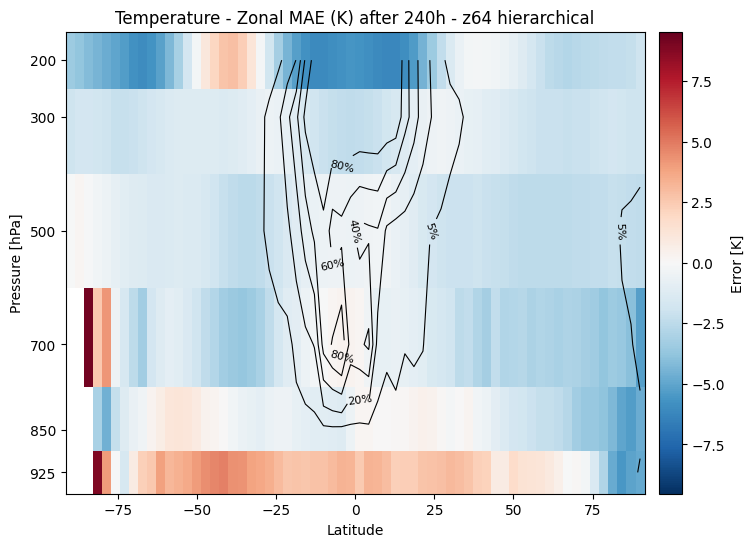

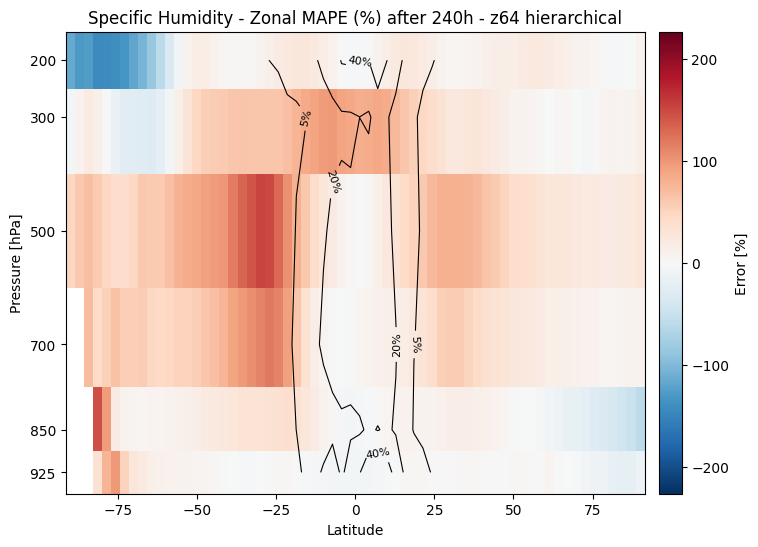

Processing 200 hPa ...
<xarray.DataArray 'temperature' (latitude: 64)> Size: 256B
dask.array<mean_agg-aggregate, shape=(64,), dtype=float32, chunksize=(32,), chunktype=numpy.ndarray>
Coordinates:
  * latitude              (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
    level                 float32 4B 200.0
    prediction_timedelta  timedelta64[ns] 8B 10 days
Processing 300 hPa ...
<xarray.DataArray 'temperature' (latitude: 64)> Size: 256B
dask.array<mean_agg-aggregate, shape=(64,), dtype=float32, chunksize=(32,), chunktype=numpy.ndarray>
Coordinates:
  * latitude              (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
    level                 float32 4B 300.0
    prediction_timedelta  timedelta64[ns] 8B 10 days
Processing 500 hPa ...
<xarray.DataArray 'temperature' (latitude: 64)> Size: 256B
dask.array<mean_agg-aggregate, shape=(64,), dtype=float32, chunksize=(32,), chunktype=numpy.ndarray>
Coordinates:
  * latitude              (latitude) float64 512B -90.0 -87.14 .

In [ ]:
for key in range(1,3): # Specific humidity

    if key == 1:
        short_name='Temperature'
        use_percentage=False
    elif key==2:
        short_name='Specific Humidity'
        use_percentage=True

    max_past_values = {}
    for plevel in [int(x) for x in ng_past_truth.level.values]:
        max_past_value = get_min_max_of_var(key, plevel=plevel)
        max_past_values[int(plevel)] = max_past_value
    # TODO calculate amount of extrapolation per (latitude, pressure level) in percent, and plot it on top with contourf

    display_name, unit, variable, plevel = plot.KEY_VARIABLES[key]
    steps = [10 * 24]
    hours_into_future=steps[0]
    
    save_to=base_save_folder_past+'zonal_cross_section_plots/' if past else base_save_folder_future+'zonal_cross_section_plots/'
    create_folder_if_not_exists(save_to)
    save_name=f'{variable}_experiment_2.png'
    print(save_to)
    
    
    # Load truth & forecast datasets
    ds_test_truth, ds_test_forecast = (
        get_datasets_after(ng_past_truth, ng_past_forecasts, hours_into_future)
        if past
        else get_datasets_after(ng_future_truth, ng_future_forecasts, hours_into_future)
    )
    
    truth = ds_test_truth[variable]
    forecast = ds_test_forecast[variable]
    # --- Process each level separately ---
    zonal_means = []
    extrap_means = []
    
    for plevel in [int(x) for x in truth.level.values]:
        print(f"Processing {plevel} hPa ...")
        
        truth_level = truth.sel(level=plevel)
        forecast_level = forecast.sel(level=plevel)
    
         # Compute % difference safely
        if use_percentage:
            data_level = (forecast_level - truth_level) / (np.abs(truth_level)) * 100
        else:
            data_level = forecast_level - truth_level # Compute absolute difference
    
        # Compute zonal mean (longitude)
        if "longitude" in data_level.dims:
            zonal_mean = data_level.mean(dim="longitude", skipna=True)
        else:
            zonal_mean = data_level
    
        # Average over time if present
        if "time" in zonal_mean.dims:
            zonal_mean = zonal_mean.mean(dim="time", skipna=True)
    
        # Store result with level coordinate
        zonal_means.append(zonal_mean.expand_dims("level"))
        print(zonal_mean)
        # fraction of truth values that exceed max_past_value
        threshold = max_past_values[plevel]   # shape (lat,)

        # broadcast threshold to truth_level shape (lat, lon, time)
        threshold_bc = threshold.broadcast_like(truth_level)

        # compute extrap lat-by-lat
        extrap_level = ((truth_level > threshold_bc)
                        .mean(dim=("longitude","time")) * 100)

        extrap_means.append(extrap_level.expand_dims("level"))
    
    # --- Combine all processed levels ---
    zonal_mean_all = xr.concat(zonal_means, dim="level")
    extrap_all = xr.concat(extrap_means, dim="level")
    
    # --- Extract coordinates and data ---
    lat = zonal_mean_all["latitude"].values
    plev = zonal_mean_all["level"].values
    vals = zonal_mean_all.values
    extrap_vals = extrap_all.values
    # vals = np.ma.masked_invalid(vals)  # NaN-safe masking
    
    # --- Plot ---
    fig, ax = plt.subplots(figsize=(9, 6))
    bounds_val = max(max(abs(np.nanmin(vals)), abs(np.nanmax(vals))),max_val[key])
    cf = ax.pcolormesh(
        lat,
        plev,
        vals,
        cmap="RdBu_r",
        shading="auto",
        vmin=-bounds_val,
        vmax=bounds_val,
    )
    CS = ax.contour(
        lat,
        plev,
        extrap_vals,
        levels=[5, 20, 40, 60, 80],   # choose contour levels
        colors="black",
        linewidths=0.8
    )
    ax.clabel(CS, inline=True, fmt="%d%%", fontsize=8)
    print(f'Max value: {bounds_val}')
    if bounds_val>max_val[key]:
        max_val[key] = bounds_val
    ax.invert_yaxis()
    ax.set_xlabel("Latitude")
    ax.set_yticks(plev)
    ax.set_ylabel("Pressure [hPa]")
    ax.set_title(f"{short_name} - Zonal {'MAPE' if use_percentage else 'MAE'} ({'%' if use_percentage else unit}) after {hours_into_future}h - {current_model_resolution}")
    
    cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
    cbar.set_label(f"Error [{'%' if use_percentage else unit}]")
    plt.savefig(save_to+save_name, bbox_inches="tight", dpi=600)


# Plot temp and rel hum per level, on top the difference between past average and future average (truth)

Evaluating model: NextGEMS z64 Multilevel Graph
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative_z64/plots/hist/
    Starting with a step length of 39 (==240 hours)
Processing 50 hPa ...
Processing 100 hPa ...
Processing 150 hPa ...
Processing 200 hPa ...
Processing 250 hPa ...
Processing 300 hPa ...
Processing 400 hPa ...
Processing 500 hPa ...
Processing 600 hPa ...
Processing 700 hPa ...
Processing 850 hPa ...
Processing 925 hPa ...
Processing 1000 hPa ...
    Starting with a step length of 39 (==240 hours)
Processing 50 hPa ...
Processing 100 hPa ...
Processing 150 hPa ...
Processing 200 hPa ...
Processing 250 hPa ...
Processing 300 hPa ...
Processing 400 hPa ...
Processing 500 hPa ...
Processing 600 hPa ...
Processing 700 hPa ...
Processing 850 hPa ...
Processing 925 hPa ...
Processing 1000 hPa ...
Evaluating model: NextGEMS z128 Multilevel Graph
/home/hk-project-pai00005/xo8179/neural_lam_f

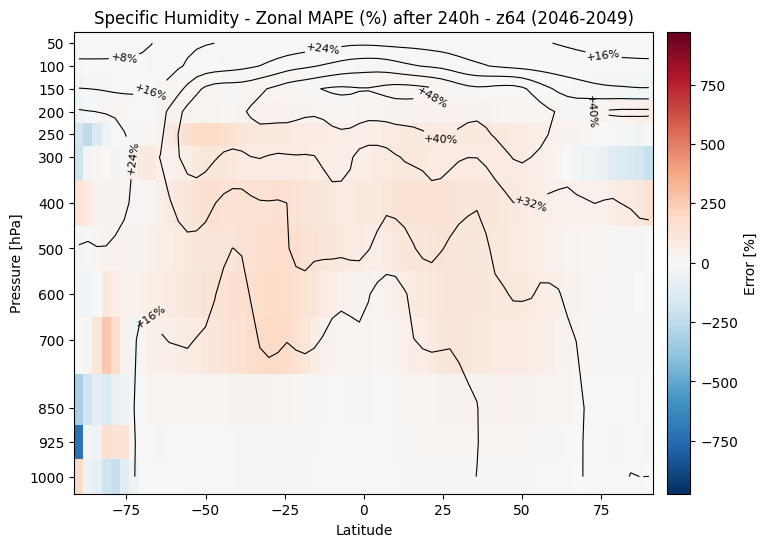

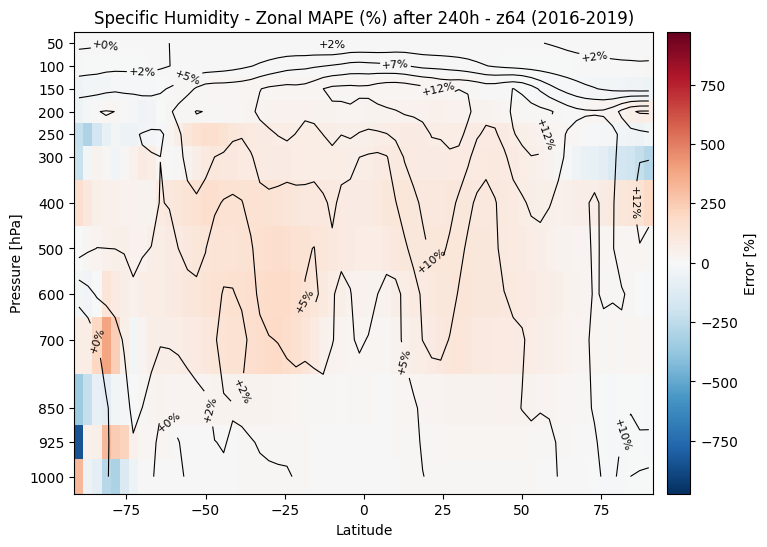

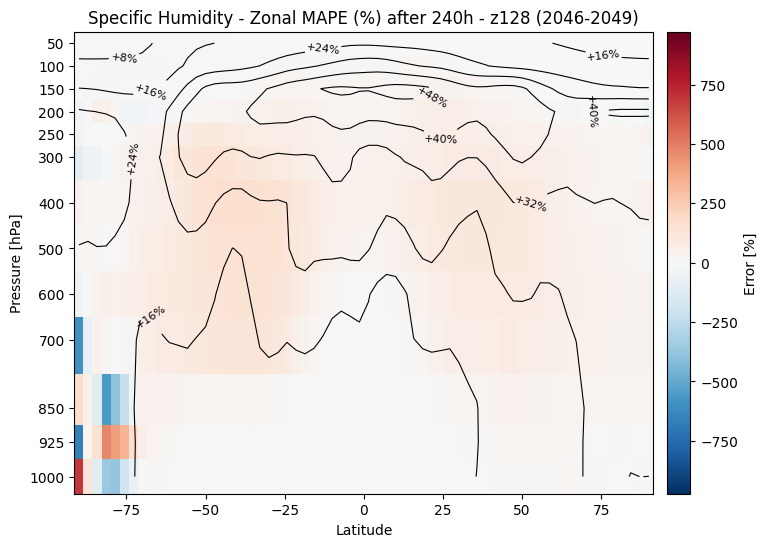

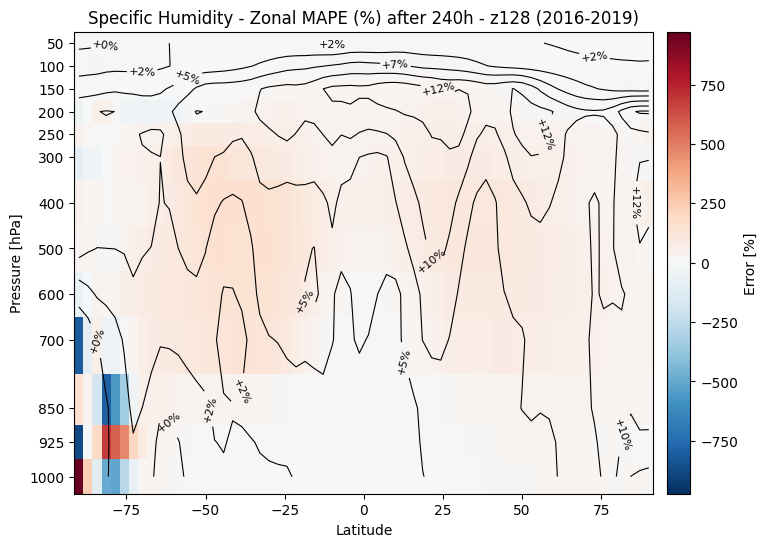

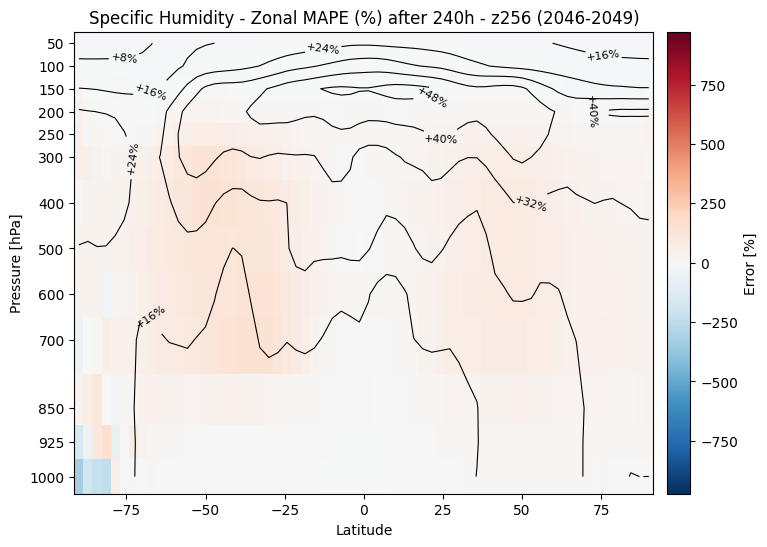

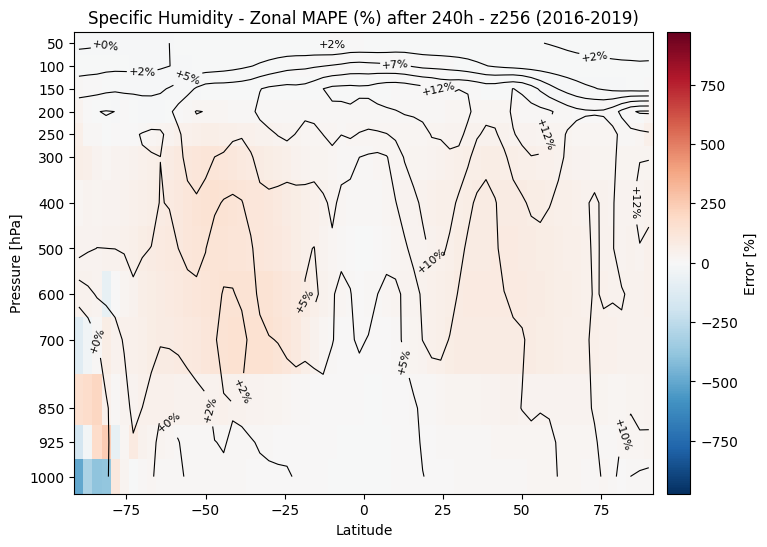

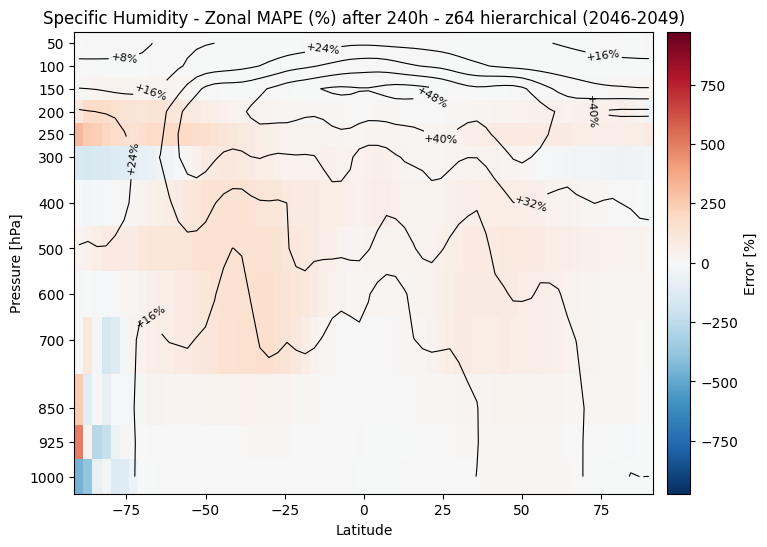

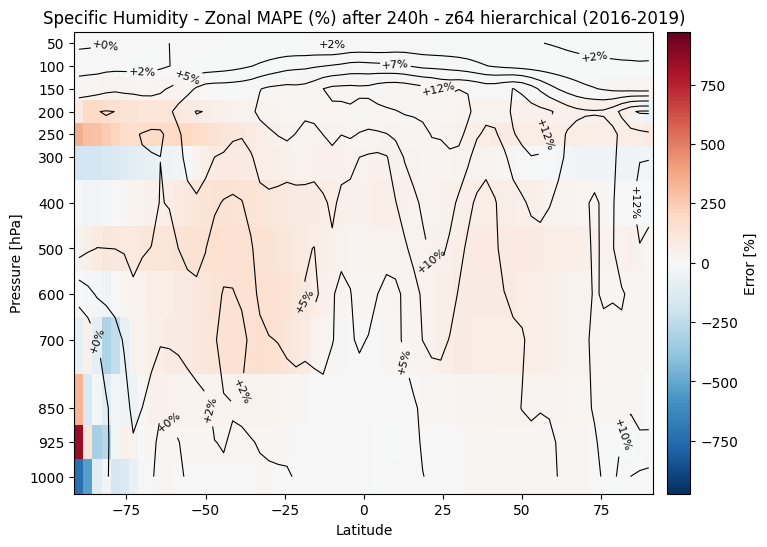

In [19]:


model_resolution = ['z64 era5', 'z64', 'z128','z256','z64 hierarchical']
model_idx=3

for key in range(2,3): # Specific humidity
        
    if key == 1:
        short_name='Temperature'
        use_percentage=False
    elif key==2:
        short_name='Specific Humidity'
        use_percentage=True

    display_name, unit, variable, plevel = plot.KEY_VARIABLES[key]
    mean_past_values = {}
    for plevel in [int(x) for x in ng_past_truth.level.values]:
        mean_past_value = get_mean_of_var(key, plevel=plevel)
        mean_past_values[int(plevel)] = mean_past_value
    
    all_vals = [[],[]]
    all_shift_vals = [[],[]]
    max_val=0
    min_val=0
    
    for model_idx in range(1,len(model_resolution)):
    
        current_model_resolution = model_resolution[model_idx]
        selected_model_past=plot.PAST_MODELS_NG_era5[model_idx]
        selected_model_future=plot.FUTURE_MODELS_NG_era5[model_idx]
        print(f'Evaluating model: {selected_model_past["model_name"]}')
        
        base_save_folder_past = selected_model_past['plot_folder']
        base_save_folder_future = selected_model_future['plot_folder']
        
        ng_past_forecasts = xr.open_zarr(selected_model_past['forecasts'], decode_timedelta=True).astype(np.float32)
        ng_future_forecasts = xr.open_zarr(selected_model_future['forecasts'], decode_timedelta=True).astype(np.float32)
        
        ng_past_truth = xr.open_zarr(selected_model_past['ground_truth']).astype(np.float32)
        ng_future_truth = xr.open_zarr(selected_model_future['ground_truth']).astype(np.float32)
        
        create_folder_if_not_exists(base_save_folder_past)
        create_folder_if_not_exists(base_save_folder_future)
        
        past = False
        print(base_save_folder_past)
        
        
        for past in [0,1]:
            steps = [10 * 24]
            hours_into_future=steps[0]
        
            # Load truth & forecast datasets
            ds_test_truth, ds_test_forecast = (
                get_datasets_after(ng_past_truth, ng_past_forecasts, hours_into_future)
                if past
                else get_datasets_after(ng_future_truth, ng_future_forecasts, hours_into_future)
            )
            
            truth = ds_test_truth[variable]
            forecast = ds_test_forecast[variable]
            # --- Process each level separately ---
            zonal_means = []
            zonal_shifts = []
            
            for plevel in [int(x) for x in truth.level.values]:
                print(f"Processing {plevel} hPa ...")
                
                truth_level = truth.sel(level=plevel)
                forecast_level = forecast.sel(level=plevel)
            
                 # Compute % difference safely
                if use_percentage:
                    data_level = (forecast_level - truth_level) / (np.abs(truth_level)) * 100
                    data_shift = (truth_level.mean(dim='time') - mean_past_values[plevel]) / (np.abs(mean_past_values[plevel])) * 100
                else:
                    data_level = forecast_level - truth_level # Compute absolute difference
                    data_shift = truth_level.mean(dim='time') - mean_past_values[plevel]
            
                # Compute zonal mean (longitude)
                if "longitude" in data_level.dims:
                    zonal_mean = data_level.mean(dim="longitude")
                    zonal_shift = data_shift.mean(dim="longitude")
                else:
                    zonal_mean = data_level
                    zonal_shift = data_shift
            
                # Average over time if present
                if "time" in zonal_mean.dims:
                    zonal_mean = zonal_mean.mean(dim="time")
            
                # Store result with level coordinate
                zonal_means.append(zonal_mean.expand_dims("level"))
                zonal_shifts.append(zonal_shift.expand_dims("level"))
                
            
            # --- Combine all processed levels ---
            zonal_mean_all = xr.concat(zonal_means, dim="level")
            zonal_shift_all = xr.concat(zonal_shifts, dim="level")
            
            # --- Extract coordinates and data ---
            lat = zonal_mean_all["latitude"].values
            plev = zonal_mean_all["level"].values
            vals = zonal_mean_all.values
            shift_vals = zonal_shift_all.values
            if np.max(vals) > max_val:
                max_val = np.max(vals)
            if np.min(vals) > min_val:
                min_val = np.min(vals)

            all_vals[past].append(vals)
            all_shift_vals[past].append(shift_vals)

    for model_idx in range(1,len(model_resolution)):
    
        current_model_resolution = model_resolution[model_idx]
        selected_model_past=plot.PAST_MODELS_NG_era5[model_idx]
        selected_model_future=plot.FUTURE_MODELS_NG_era5[model_idx]
        print(f'Evaluating model: {selected_model_past["model_name"]}')
        
        base_save_folder_past = selected_model_past['plot_folder']
        base_save_folder_future = selected_model_future['plot_folder']
        for past in [0,1]:
            
            save_to=base_save_folder_past+'zonal_cross_section_plots/' if past else base_save_folder_future+'zonal_cross_section_plots/'
            create_folder_if_not_exists(save_to)
            save_name=f'{variable}_experiment.png'
            print(save_to)
    
            vals = all_vals[past][model_idx-1]
            shift_vals = all_shift_vals[past][model_idx-1]
            
            # --- Plot ---
            fig, ax = plt.subplots(figsize=(9, 6))
            bounds_val = max(abs(min_val), abs(max_val))
            cf = ax.pcolormesh(
                lat,
                plev,
                vals,
                cmap="RdBu_r",
                shading="auto",
                vmin=-bounds_val,
                vmax=bounds_val,
            )
            CS = ax.contour(
                lat,
                plev,
                shift_vals,
                #levels=[-1, -0.5, 0, 0.5, 1] if past else [-1, 0, 1, 2, 3],   # choose contour levels
                colors="black",
                linewidths=0.8
            )
            ax.clabel(CS, inline=True, fmt="%+d%%" if use_percentage else "%+.1f", fontsize=8)
            ax.invert_yaxis()
            ax.set_xlabel("Latitude")
            ax.set_yticks(plev)
            ax.set_ylabel("Pressure [hPa]")
            ax.set_title(f"{short_name} - Zonal {'MAPE' if use_percentage else 'MAE'} ({'%' if use_percentage else unit}) after {hours_into_future}h - {current_model_resolution} ({'2016-2019' if past else '2046-2049'})")
            
            cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
            cbar.set_label(f"Error [{'%' if use_percentage else unit}]")
            plt.savefig(save_to+save_name, bbox_inches="tight", dpi=600)

Evaluating model: NextGEMS z64 Multilevel Graph
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative_z64/plots/future/zonal_cross_section_plots/
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative_z64/plots/hist/zonal_cross_section_plots/
Evaluating model: NextGEMS z128 Multilevel Graph
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative_z128/plots/future/zonal_cross_section_plots/
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative_z128/plots/hist/zonal_cross_section_plots/
Evaluating model: NextGEMS z256 Multilevel Graph
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_equiangular_with

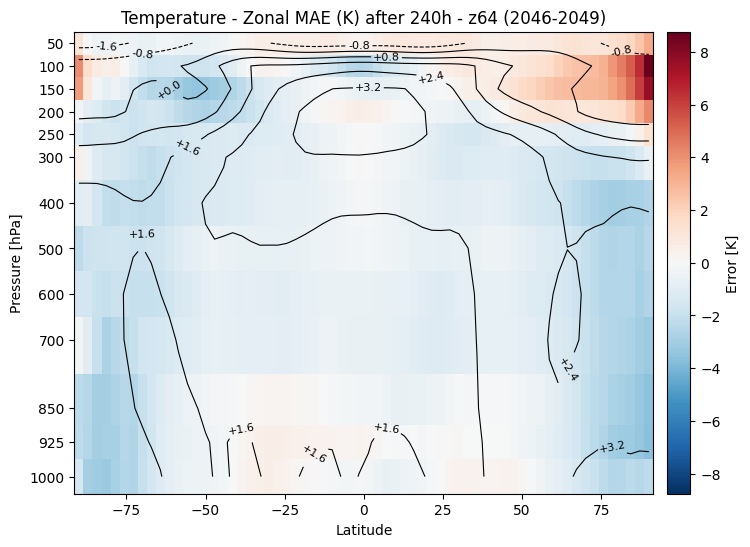

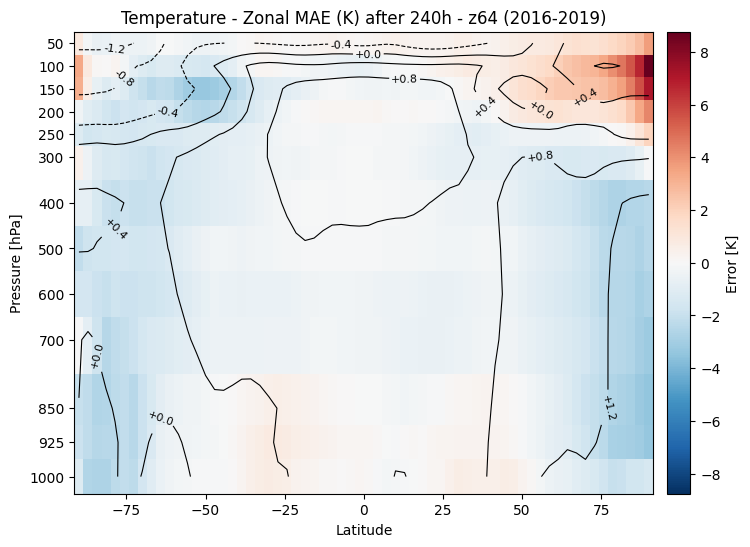

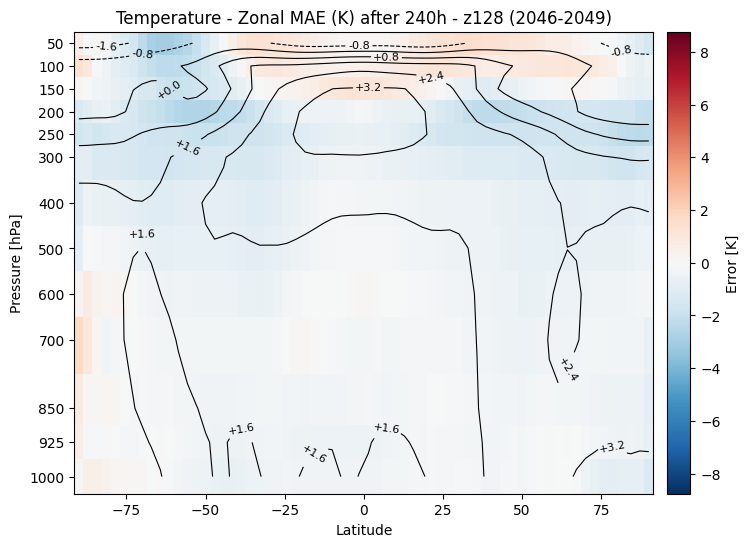

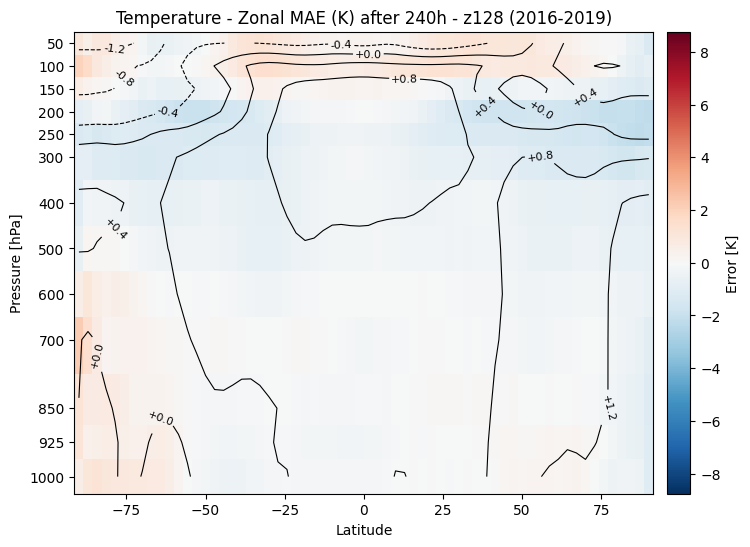

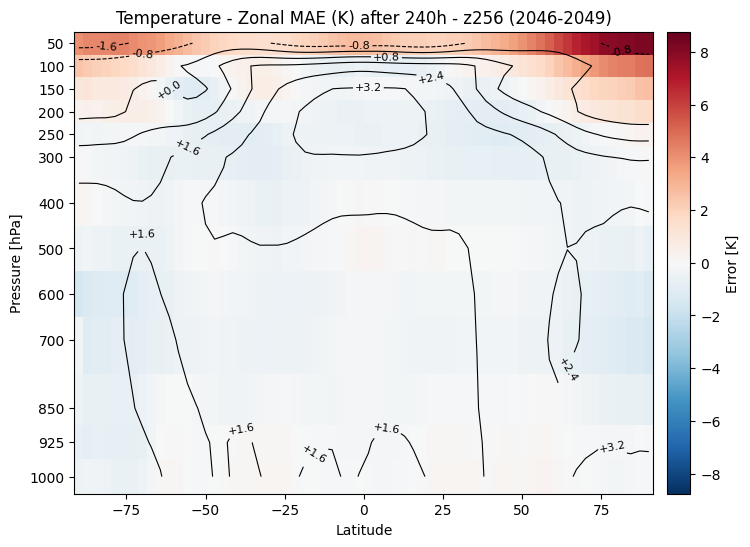

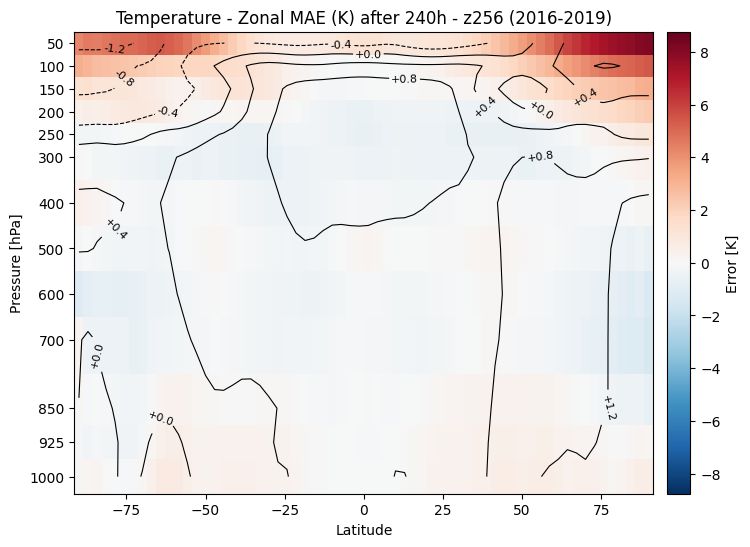

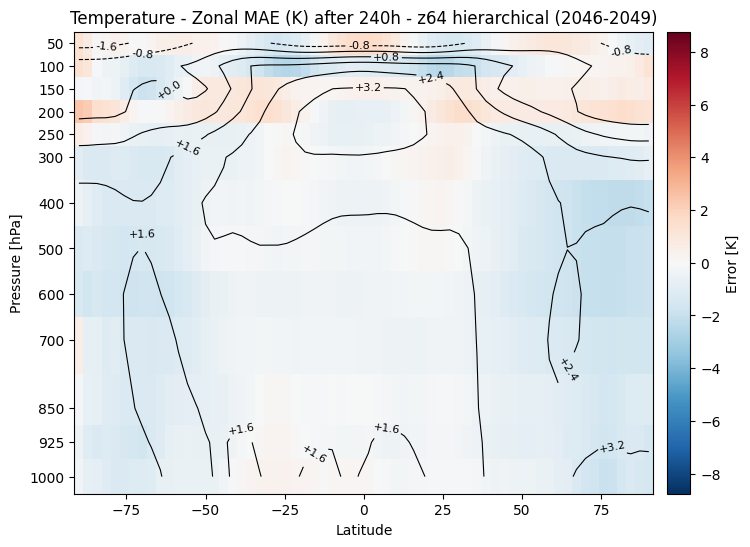

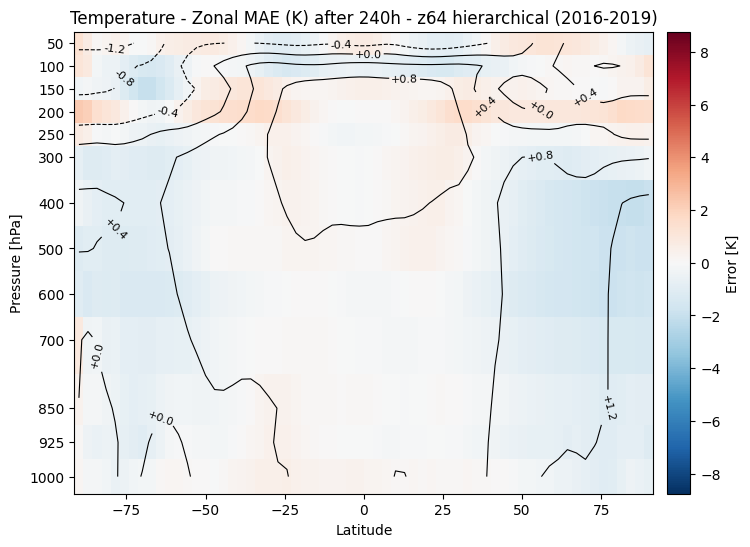

In [18]:
for model_idx in range(1,len(model_resolution)):
    
    current_model_resolution = model_resolution[model_idx]
    selected_model_past=plot.PAST_MODELS_NG_era5[model_idx]
    selected_model_future=plot.FUTURE_MODELS_NG_era5[model_idx]
    print(f'Evaluating model: {selected_model_past["model_name"]}')
    
    base_save_folder_past = selected_model_past['plot_folder']
    base_save_folder_future = selected_model_future['plot_folder']
    for past in [0,1]:
        
        save_to=base_save_folder_past+'zonal_cross_section_plots/' if past else base_save_folder_future+'zonal_cross_section_plots/'
        create_folder_if_not_exists(save_to)
        save_name=f'{variable}_experiment.png'
        print(save_to)

        vals = all_vals[past][model_idx-1]
        shift_vals = all_shift_vals[past][model_idx-1]
        
        # --- Plot ---
        fig, ax = plt.subplots(figsize=(9, 6))
        bounds_val = max(abs(min_val), abs(max_val))
        cf = ax.pcolormesh(
            lat,
            plev,
            vals,
            cmap="RdBu_r",
            shading="auto",
            vmin=-bounds_val,
            vmax=bounds_val,
        )
        CS = ax.contour(
            lat,
            plev,
            shift_vals,
            #levels=[-1, -0.5, 0, 0.5, 1] if past else [-1, 0, 1, 2, 3],   # choose contour levels
            colors="black",
            linewidths=0.8
        )
        ax.clabel(CS, inline=True, fmt="%+d%%" if use_percentage else "%+.1f", fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel("Latitude")
        ax.set_yticks(plev)
        ax.set_ylabel("Pressure [hPa]")
        ax.set_title(f"{short_name} - Zonal {'MAPE' if use_percentage else 'MAE'} ({'%' if use_percentage else unit}) after {hours_into_future}h - {current_model_resolution} ({'2016-2019' if past else '2046-2049'})")
        
        cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.02)
        cbar.set_label(f"Error [{'%' if use_percentage else unit}]")
        plt.savefig(save_to+save_name, bbox_inches="tight", dpi=600)

In [24]:
abs1 = abs(np.nanmin(vals))
abs2 = abs(np.nanmax(vals))
max1=max(abs1,abs2)
#bounds_val = max(, ,max_val[key])

In [23]:
del max

In [126]:
print(max_val)

9.154826


    Starting with a step length of 39 (==240 hours)


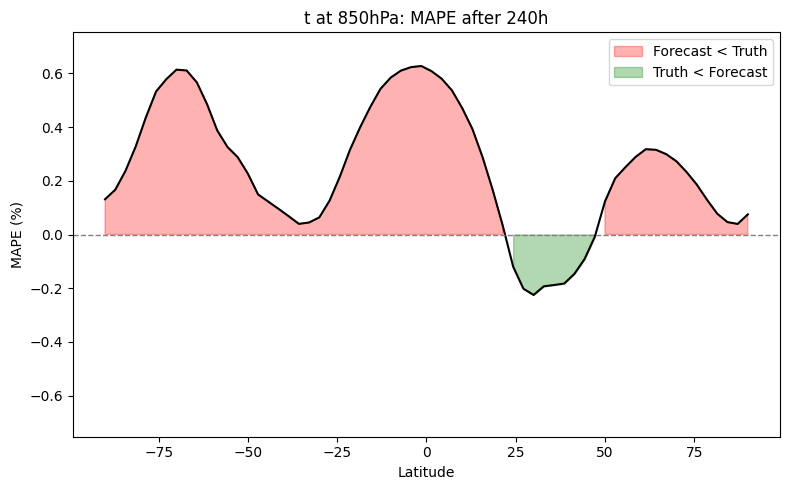

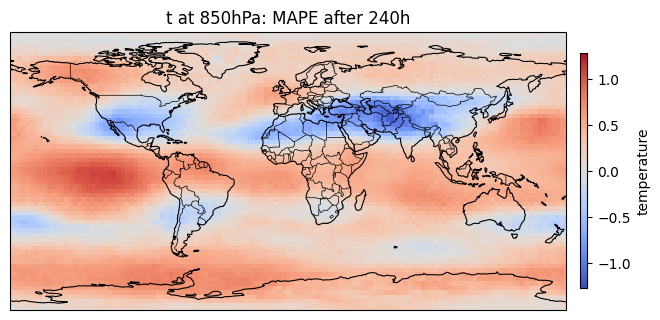

In [ ]:
save_to=base_save_folder_past+'zonal_plots/' if past else base_save_folder_future+'zonal_plots/'
create_folder_if_not_exists(save_to)
# steps=[24, 5*24, 10*24]
steps=[10*24]
num_vars = len(plot.KEY_VARIABLES)
mask = xr.open_dataset('valid_mask_past.zarr') if past else xr.open_dataset('valid_mask_future.zarr')

for var_index in range(1,2):
# for var_index in range(6,7):
    
    display_name, unit, variable, plevel = plot.KEY_VARIABLES[var_index]
    plevel=300
    for i, hours_into_future in enumerate(steps):
        save_name=f'zonal_{variable}_at_{plevel if plevel else "surface"}_after_{hours_into_future}.pdf'
        
        ds_test_truth, ds_test_forecast = get_datasets_after(ng_past_truth, ng_past_forecasts, hours_into_future) if past else get_datasets_after(ng_future_truth, ng_future_forecasts, hours_into_future) 
                
        truth = ds_test_truth.sel(level=plevel)[variable] if plevel else ds_test_truth[variable]
        forecast=ds_test_forecast.sel(level=plevel)[variable] if plevel else ds_test_forecast[variable]
            
        diff = (truth-forecast)/truth * 100
        if plevel and plevel>500:
            mask_sel=mask[f'temperature_{plevel}']
            print(f"    Applying mask... Minimum value after applying mask: {truth.where(mask_sel).min().values}")
            diff = diff.where(mask_sel)
        
        plot.plot_zonal_plot(
            diff,
            f'{display_name}: MAPE after {hours_into_future}h',
            'MAPE (%)',
            vbounds=None,
            base_save_folder="./",
            save_name="single_plot",
            label_above="Forecast < Truth",
            label_below="Truth < Forecast",
            centered_around=0,
            color_above="red",
            color_below="green",
            show=True
        )

        if "time" in diff.dims:
            mean = diff.mean(dim="time", skipna=True)
            # if plevel and plevel>500:
            #     mean = mean.where(mask_sel)
            plot.plot_single_plot(mean.T, f'{display_name}: MAPE after {hours_into_future}h', variable, None, 'coolwarm', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_experiment', show=True)

In [ ]:
plot.plot_single_plot(ukesm_historical_truth_equiangular_wp_cons.isel(time=-1).sel(level=plevel)[variable].T, f'temp forecast at {plevel}', 'temperature', None, 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_experiment', show=True)

In [20]:
fig.savefig(save_to+save_name, bbox_inches="tight", dpi=600)

In [11]:
computed = truth.where(mask_sel).compute()
min_coords = computed.where(computed == 0, drop=True)
print(truth)
print(min_coords.time)

<xarray.DataArray 'total_precipitation_6hr' (time: 2860, longitude: 128,
                                             latitude: 64)> Size: 94MB
dask.array<getitem, shape=(2860, 128, 64), dtype=float32, chunksize=(20, 128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
  * time       (time) object 23kB 2097-01-11 06:00:00 ... 2100-12-30 18:00:00
Attributes:
    description:  Computed from 3-hourly precipitation rate (kg m-2 s-1) usin...
    long_name:    Total precipitation accumulated over 6 hours
    units:        kg m-2
<xarray.DataArray 'time' (time: 2860)> Size: 23kB
array([cftime.Datetime360Day(2097, 1, 11, 6, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2097, 1, 11, 18, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2097, 1, 12, 6, 0, 0, 0, has_year_zero=True), ...,
       cftime.Datetime360Day(2100, 12,

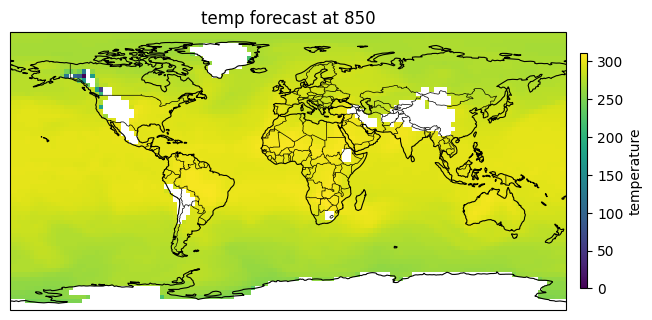

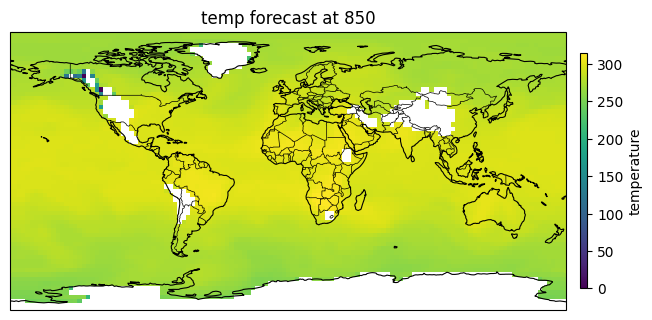

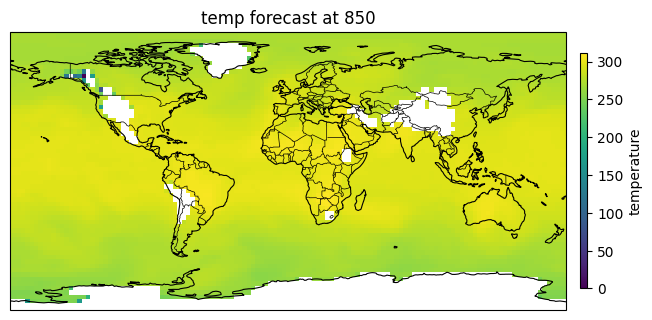

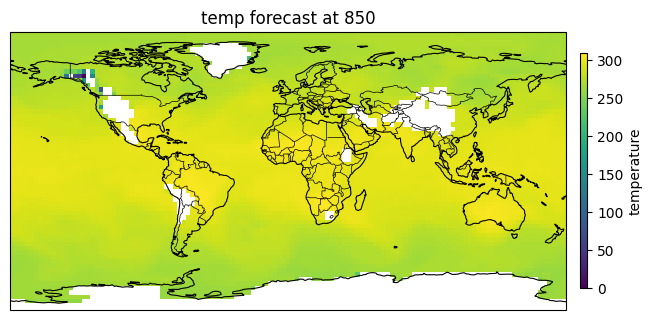

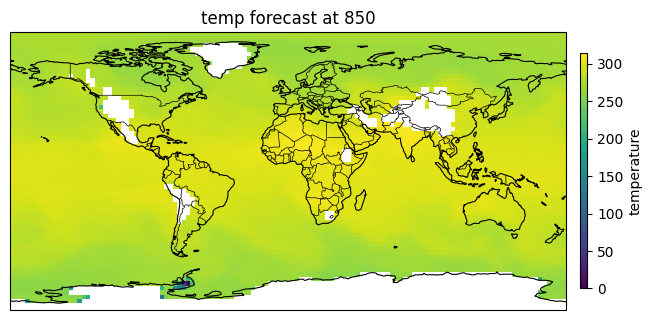

In [12]:
for t in min_coords.time:
    plot.plot_single_plot(truth.sel(time=t).where(mask_sel).T, f'temp forecast at {plevel}', 'temperature', None, 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_experiment', show=True)

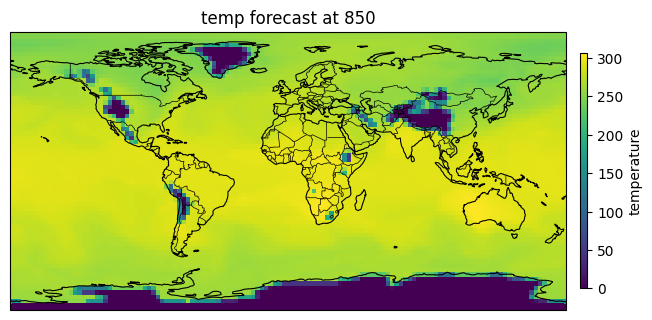

In [17]:
plot.plot_single_plot(ukesm_historical_truth_equiangular_wp_cons.isel(time=-1).sel(level=plevel)[variable].T, f'temp forecast at {plevel}', 'temperature', None, 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_experiment', show=True)

In [18]:
print(ukesm_historical_truth_equiangular_wp_cons.sel(level=plevel)[variable])

<xarray.DataArray 'temperature' (time: 43199, longitude: 128, latitude: 64)> Size: 1GB
dask.array<getitem, shape=(43199, 128, 64), dtype=float32, chunksize=(40, 128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
    level      float32 4B 850.0
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
  * time       (time) object 346kB 1985-01-01 06:00:00 ... 2014-12-30 18:00:00
Attributes:
    date:           01/01/50
    long_name:      Temperature T
    name:           temp
    source:         Unified Model Output (Vn10.9):
    standard_name:  air_temperature
    time:           00:00
    title:          Temperature T
    units:          K
    valid_max:      312.37158203125
    valid_min:      0.0


[200. 300. 500. 700. 850. 925.]


In [46]:
plevel = 700
mask_threshold=plot.MASK_VALUES_UKESM_TEMPERATURE[str(plevel)]
truth = ds_test_truth.sel(level=plevel)[variable].isel(time=12*60)
forecast=ds_test_forecast.sel(level=plevel)[variable].isel(time=12*60)
plot.plot_single_plot(truth.where(truth >= mask_threshold).T, f'temp at {plevel}', 'temperature', (mask_threshold,350), 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test')
plot.plot_single_plot(forecast.where(truth >= mask_threshold).T, f'temp forecast at {plevel}', 'temperature', (mask_threshold,350), 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_forecast')

In [55]:
print(ds_test_truth.level.values)
plevel = 850

[200. 300. 500. 700. 850. 925.]


In [67]:
lowest_temp = ukesm_future_truth_equiangular_wp_cons.sel(level=plevel)[variable].min(dim='time')
print(lowest_temp)
plot.plot_single_plot(lowest_temp.T, f'Lowest temperature per coordinate at {plevel}hPa', 'temperature', None, 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'lowest_temp_val_850')

<xarray.DataArray 'temperature' (longitude: 128, latitude: 64)> Size: 33kB
dask.array<_nanmin_skip-aggregate, shape=(128, 64), dtype=float32, chunksize=(128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
    level      float32 4B 850.0
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2


In [68]:
from tqdm import tqdm
experiment = lowest_temp.where(lowest_temp >= mask_threshold).copy()
print(experiment.values.shape)
vals = experiment.values

plot.plot_single_plot(experiment.T, f'Lowest temperature per coordinate at {plevel}hPa (Impossible masked out)', 'temperature', (mask_threshold,350), 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'lowest_temp_val_850_impossible_masked')

(128, 64)


In [62]:
shifted_1 = experiment.isel(longitude=slice(0,-1))
shifted_2 = experiment.isel(longitude=slice(1,None))
shifted_2['longitude'] = shifted_1.longitude
diff=(shifted_1-shifted_2)
# pad diff to match experiment dims
pad_lat = experiment.latitude.size - diff.latitude.size
pad_lon = experiment.longitude.size - diff.longitude.size
# plot.plot_single_plot(diff.T, f'temp forecast at {plevel}', 'temperature', None, 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_experiment', show=True)

diff_padded = xr.concat(
    [xr.full_like(diff.isel(latitude=slice(-pad_lat, None), longitude=slice(-pad_lon, None)), -70), diff],
    dim='longitude'
)


diff_padded_left = diff_padded.fillna(0)
diff_padded_left['longitude'] = truth.longitude
# plot.plot_single_plot(experiment.T, f'temp forecast at {plevel}', 'temperature', None, 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_experiment', show=True)
# plot.plot_single_plot(experiment.where(diff_padded_left<20).T, f'temp forecast at {plevel}', 'temperature', None, 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_experiment', show=True)

In [63]:
shifted_1 = experiment.isel(longitude=slice(0,-1))
shifted_2 = experiment.isel(longitude=slice(1,None))
shifted_1['longitude'] = shifted_2.longitude
diff=(shifted_2-shifted_1)
# pad diff to match experiment dims
pad_lat = experiment.latitude.size - diff.latitude.size
pad_lon = experiment.longitude.size - diff.longitude.size

diff_padded = xr.concat(
    [diff, xr.full_like(diff.isel(latitude=slice(-pad_lat, None), longitude=slice(-pad_lon, None)), -70)],
    dim='longitude'
)


diff_padded_right = diff_padded.fillna(0)
diff_padded_right['longitude'] = truth.longitude

In [64]:
# Shift experiment data up and down along latitude
shifted_up = experiment.isel(latitude=slice(0, -1))   # all except last latitude
shifted_down = experiment.isel(latitude=slice(1, None))  # all except first latitude
shifted_down['latitude'] = shifted_up.latitude  # align coordinates

# Compute difference between neighboring latitude bands
diff_lat = shifted_up - shifted_down

# Pad diff_lat to match experiment dimensions
pad_lat = experiment.latitude.size - diff_lat.latitude.size
pad_lon = experiment.longitude.size - diff_lat.longitude.size



# Pad along latitude to restore full grid
diff_lat_padded = xr.concat(
    [xr.full_like(diff_lat.isel(latitude=slice(-pad_lat, None)), -70), diff_lat],
    dim='latitude'
)

# Replace NaNs and realign coordinates
diff_padded_down = diff_lat_padded.fillna(0)
diff_padded_down['latitude'] = truth.latitude


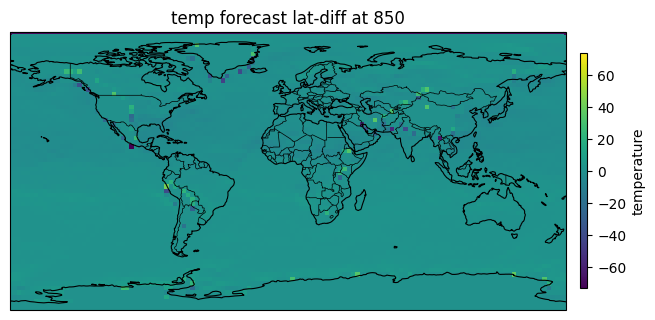

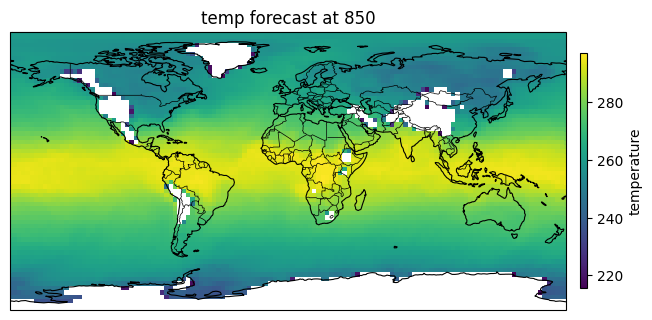

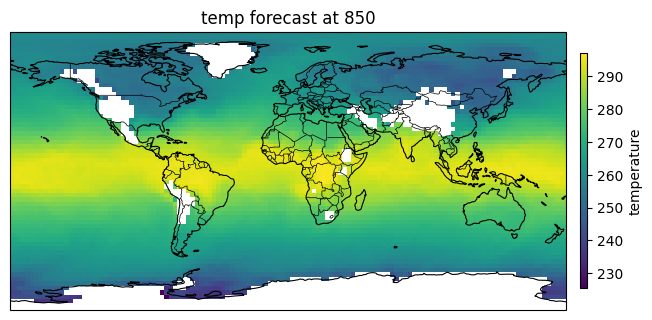

In [69]:
# Shift experiment data up and down along latitude
shifted_up = experiment.isel(latitude=slice(0, -1))   # all except last latitude
shifted_down = experiment.isel(latitude=slice(1, None))  # all except first latitude
shifted_up['latitude'] = shifted_down.latitude  # align coordinates

# Compute difference between neighboring latitude bands
diff_lat = shifted_down - shifted_up

# Pad diff_lat to match experiment dimensions
pad_lat = experiment.latitude.size - diff_lat.latitude.size
pad_lon = experiment.longitude.size - diff_lat.longitude.size



# Pad along latitude to restore full grid
diff_lat_padded = xr.concat(
    [diff_lat,xr.full_like(diff_lat.isel(latitude=slice(-pad_lat, None)), -70)],
    dim='latitude'
)

# Replace NaNs and realign coordinates
diff_padded_up = diff_lat_padded.fillna(0)
diff_padded_up['latitude'] = truth.latitude

# Plot the difference field (optional diagnostic)
plot.plot_single_plot(
    diff_padded_up.T,
    f'temp forecast lat-diff at {plevel}',
    'temperature',
    None,
    'viridis',
    "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/",
    'test_experiment_latdiff',
    show=True
)

# Plot original and filtered results
plot.plot_single_plot(
    experiment.T,
    f'temp forecast at {plevel}',
    'temperature',
    None,
    'viridis',
    "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/",
    'test_experiment_lat',
    show=True
)
thresh=15
temp_mask = experiment.where(diff_padded_up < thresh).where(diff_padded_down < thresh).where(diff_padded_left < thresh).where(diff_padded_right < thresh)
plot.plot_single_plot(
    temp_mask.T,
    f'temp forecast at {plevel}',
    'temperature',
    None,
    'viridis',
    "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/",
    'test_experiment_lat_filtered',
    show=True
)
thresh=10
temp_mask = experiment.where(diff_padded_up < thresh).where(diff_padded_down < thresh).where(diff_padded_left < thresh).where(diff_padded_right < thresh)
plot.plot_single_plot(
    temp_mask.T,
    f'Lowest temperature per coordinate at {plevel}hPa (Impossible masked out and filtered)',
    'temperature',
    None,
    'viridis',
    "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/",
    'lowest_temp_val_850_impossible_masked_and_filtered_thresh_10'
)

In [51]:
ds = xr.open_dataset("valid_mask.zarr")
mask2 = ds[f'temperature_{plevel}']

In [54]:

mask = xr.where(temp_mask.notnull(), 1, 0)  # 1 = valid, 0 = invalid
# combined_mask = mask * mask2
# plot.plot_single_plot(
#     combined_mask.T,
#     f'temp forecast at {plevel}',
#     'temperature',
#     None,
#     'viridis',
#     "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/",
#     'test_experiment_lat_filtered',
#     show=True
# )
combined_mask = mask 
combined_mask = combined_mask.drop_vars(["level"])

combined_mask = combined_mask.chunk(longitude=-1, latitude=-1)
print(combined_mask)
combined_mask.to_dataset(name=f"temperature_{plevel}").to_zarr(f"combined_valid_mask.zarr_future", mode='a')

<xarray.DataArray 'temperature' (longitude: 128, latitude: 64)> Size: 66kB
dask.array<rechunk-merge, shape=(128, 64), dtype=int64, chunksize=(128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
    time       object 8B 2098-01-11 06:00:00


In [37]:
print(plevel)

850


In [53]:
ds = xr.open_dataset("combined_valid_mask.zarr")
print(ds)

<xarray.Dataset> Size: 198kB
Dimensions:          (latitude: 64, longitude: 128)
Coordinates:
  * latitude         (latitude) float64 512B -90.0 -87.14 -84.29 ... 87.14 90.0
  * longitude        (longitude) float64 1kB 0.0 2.812 5.625 ... 354.4 357.2
Data variables:
    temperature_700  (longitude, latitude) int64 66kB ...
    temperature_850  (longitude, latitude) int64 66kB ...
    temperature_925  (longitude, latitude) int64 66kB ...


In [20]:
make_nan = []
for ilon in tqdm(range(experiment.values.shape[0]-1)):
    for ilat in range(experiment.values.shape[1]-1):
        p1 = experiment.values[ilon][ilat]
        p2 = experiment.values[ilon][ilat+1]
        p3 = experiment.values[ilon+1][ilat]
        if not p1==np.nan and not p2==np.nan:
            if p1-p2 > 20:
                make_nan.append((ilon,ilat+1))
            elif p2-p1 > 20:
                make_nan.append((ilon,ilat))
        if not p1==np.nan and not p3==np.nan:
            if p1-p3 > 20:
                make_nan.append((ilon+1,ilat))
            elif p3-p1 > 20:
                make_nan.append((ilon,ilat))


100%|██████████| 127/127 [04:02<00:00,  1.91s/it]


In [26]:
make_nan=true_make_nan

In [32]:
for p in true_make_nan:
    print(p)
    experiment.isel(latitude=p[1], longitude=p[0]).values[...] = np.nan
plot.plot_single_plot(experiment.T, f'temp at {plevel}', 'temperature', (mask_threshold,350), 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'experiment')

(13, 36)
(13, 36)
(14, 45)
(14, 36)
(14, 36)
(14, 45)
(16, 44)
(17, 8)
(16, 44)
(17, 43)
(16, 46)
(16, 46)
(17, 8)
(17, 43)
(18, 42)
(17, 45)
(17, 45)
(18, 42)
(20, 43)
(20, 43)
(21, 8)
(22, 43)
(22, 44)
(22, 8)
(22, 43)
(22, 44)
(24, 42)
(24, 45)
(24, 7)
(24, 7)
(24, 42)
(24, 42)
(24, 45)
(26, 47)
(26, 43)
(27, 42)
(26, 47)
(27, 42)
(27, 47)
(29, 8)
(29, 41)
(29, 8)
(30, 8)
(29, 41)
(30, 41)
(30, 49)
(30, 8)
(30, 41)
(30, 49)
(31, 48)
(30, 49)
(31, 50)
(31, 8)
(31, 47)
(31, 46)
(31, 47)
(31, 47)
(31, 50)
(33, 46)
(33, 47)
(32, 50)
(32, 50)
(34, 50)
(35, 40)
(34, 50)
(35, 40)
(36, 46)
(36, 50)
(36, 50)
(37, 47)
(37, 47)
(38, 41)
(38, 43)
(38, 43)
(41, 8)
(42, 8)
(43, 8)
(44, 8)
(45, 8)
(51, 8)
(86, 49)
(86, 49)
(87, 48)
(86, 49)
(87, 44)
(88, 44)
(87, 49)
(87, 50)
(88, 44)
(89, 5)
(90, 40)
(89, 48)
(89, 48)
(90, 5)
(90, 40)
(91, 5)
(92, 38)
(92, 5)
(92, 38)
(93, 5)
(93, 39)
(93, 39)
(98, 5)
(98, 5)
(100, 28)
(100, 28)
(100, 28)
(103, 20)
(104, 27)
(104, 27)
(105, 22)
(105, 22)
(106, 24

In [ ]:
mask = xr.where(experiment.notnull(), 1, 0)  # 1 = valid, 0 = invalid
mask.to_zarr(f"valid_mask_{plevel}hPa.zarr")

In [20]:
plot.plot_single_plot(ds_test_truth['surface_temperature'].isel(time=6*60).T, f'temp at surface', 'temperature', (0,350), 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_surf')
plot.plot_single_plot(ds_test_forecast['surface_temperature'].isel(time=6*60).T, f'temp forecast at surface', 'temperature', (0,350), 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_forecast_surf')

In [ ]:
all_performance_1819 = []
all_performance_2049 = []
all_shift_map_2049 = []
all_relative_performance_error = []
all_absolute_performance_error = []
all_relative_performance_percentage = []
all_mean_truth_difference=[]
weighted_wasserstein = []
weighted_rmse_list = []
all_truth_201819 = []
all_truth_2049 = []
all_forecast_201819 = []
all_forecast_2049 = []

mixed = False
historical_year='2019'
future_year='2049'
error_after_hours = 120 # Must be dividable by 6


assert (error_after_hours % 6) == 0 and error_after_hours > 0
error_after_x_steps = int(error_after_hours / 6) - 1

# First prediction is always at 00 or 12 -> if error_after_x_steps is odd, we only look at 00 and 12 time values 
# If not, we only look at 06 and 18 time values
if error_after_x_steps % 2 == 0:
    filter_hours = [6,18]
else: filter_hours = [0,12]

if mixed:
    base_save_folder = "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_try2_z64/plots/"
else:
    # base_save_folder = "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative_z64/plots/"
    base_save_folder = "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative_z128/plots/"

for display_name, unit, variable, plevel in plot.KEY_VARIABLES:
    
    
    if mixed:
        truth_hist = nextgems_mixed_truth_1819.sel(time=historical_year).isel(time=slice(0,-1))[variable]
        truth_future = nextgems_mixed_truth_49.sel(time=future_year)[variable]
        forecast_hist = nextgems_1990_2020_mixed_z64.sel(time=historical_year)[variable].sel(time=nextgems_1990_2020_mixed_z64.time.dt.hour.isin([0, 12])).isel(time=slice(10,-10))
        forecast_future = nextgems_2049_mixed_z64.sel(time=future_year)[variable].sel(time=nextgems_2049_mixed_z64.time.dt.hour.isin([0, 12])).isel(time=slice(10,-10))
    else:
        truth_hist = nextgems_equiangular_wp_cons_truth_1819.sel(time=historical_year)[variable]
        truth_hist = truth_hist.isel(time=slice(2+error_after_x_steps,-(38-error_after_x_steps)))
        truth_hist = truth_hist.sel(time=truth_hist.time.dt.hour.isin(filter_hours))
        truth_future = nextgems_equiangular_wp_cons_truth_49.sel(time=future_year)[variable]
        truth_future = truth_future.isel(time=slice(2+error_after_x_steps,-(38-error_after_x_steps)))
        truth_future = truth_future.sel(time=truth_future.time.dt.hour.isin(filter_hours))
        forecast_hist = nextgems_1990_2020_equiangular_wp_cons_z128.sel(time=historical_year)[variable].isel(prediction_timedelta=error_after_x_steps)
        forecast_future = nextgems_2049_equiangular_wp_cons_z128.sel(time=future_year)[variable].isel(prediction_timedelta=error_after_x_steps)
        print(forecast_hist['time'])
        print(truth_hist['time'])
        forecast_hist['time'] = truth_hist['time']
        forecast_future['time'] = truth_future['time']
        
        
    if plevel:
        truth_hist = truth_hist.sel(level=plevel)
        truth_future = truth_future.sel(level=plevel)
        forecast_hist = forecast_hist.sel(level=plevel)
        forecast_future = forecast_future.sel(level=plevel)
        
    

    all_truth_201819.append(truth_hist)
    all_truth_2049.append(truth_future)
    all_forecast_201819.append(forecast_hist)
    all_forecast_2049.append(forecast_future)
    performance_1819 = rmse(truth_hist, forecast_hist)
    performance_2049 = rmse(truth_future, forecast_future)
    all_relative_performance_percentage.append((performance_2049 - performance_1819) / performance_1819 * 100)
    all_performance_1819.append(performance_1819)
    all_performance_2049.append(performance_2049)
    all_shift_map_2049.append(shift_per_gridcell(truth_hist, truth_future))
    weighted_wasserstein.append(shift_global(truth_hist, truth_future))
    weighted_rmse_1819 = weighted_rmse(truth_hist, forecast_hist)
    weighted_rmse_49 = weighted_rmse(truth_future, forecast_future)
    weighted_rmse_list.append((weighted_rmse_49 - weighted_rmse_1819) / weighted_rmse_1819 * 100)
    all_relative_performance_error.append(performance_2049 / performance_1819)
    all_absolute_performance_error.append(performance_2049 - performance_1819)
    all_mean_truth_difference.append(truth_future.mean('time') - truth_hist.mean('time'))

<xarray.DataArray 'time' (time: 710)> Size: 6kB
array(['2019-01-01T06:00:00.000000000', '2019-01-01T18:00:00.000000000',
       '2019-01-02T06:00:00.000000000', ..., '2019-12-20T18:00:00.000000000',
       '2019-12-21T06:00:00.000000000', '2019-12-21T18:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    prediction_timedelta  timedelta64[ns] 8B 00:00:00.000000120
  * time                  (time) datetime64[ns] 6kB 2019-01-01T06:00:00 ... 2...
<xarray.DataArray 'time' (time: 710)> Size: 6kB
array(['2019-01-06T12:00:00.000000000', '2019-01-07T00:00:00.000000000',
       '2019-01-07T12:00:00.000000000', ..., '2019-12-26T00:00:00.000000000',
       '2019-12-26T12:00:00.000000000', '2019-12-27T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 6kB 2019-01-06T12:00:00 ... 2019-12-27
<xarray.DataArray 'time' (time: 710)> Size: 6kB
array(['2019-01-01T06:00:00.000000000', '2019-01-01T18:00:00.000000000',
       '2019-01-02T06:00:00.

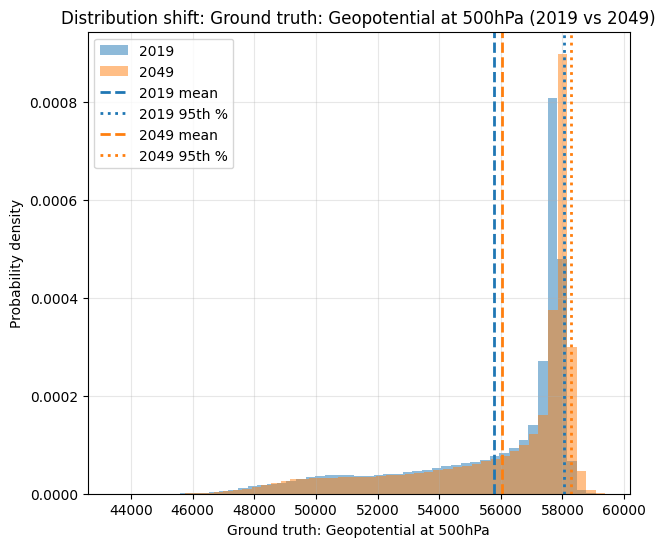

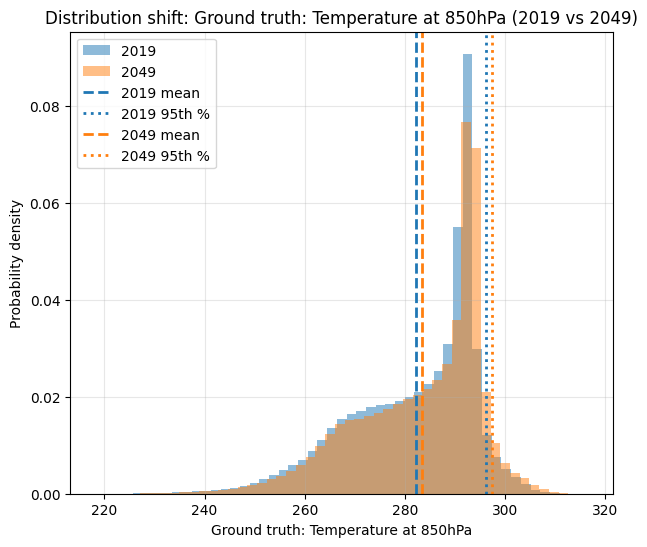

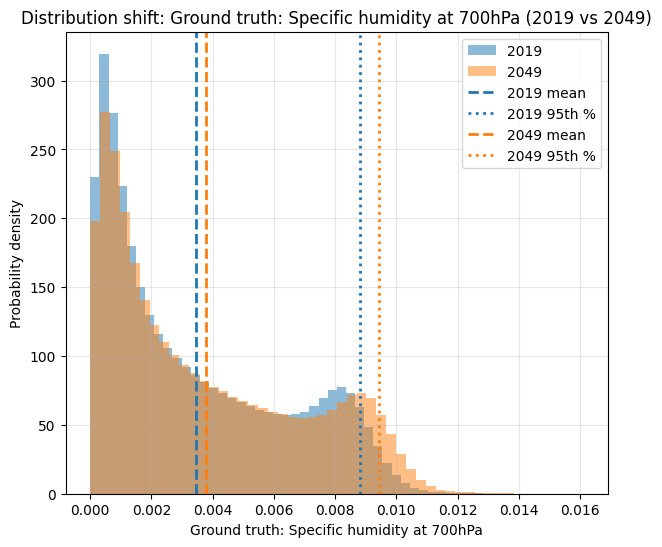

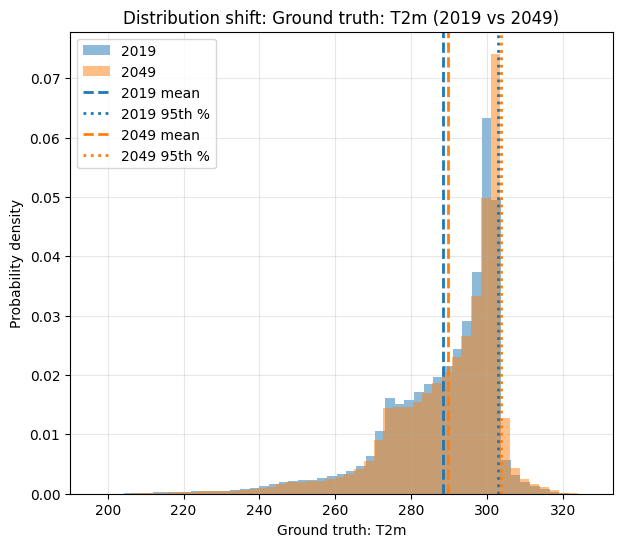

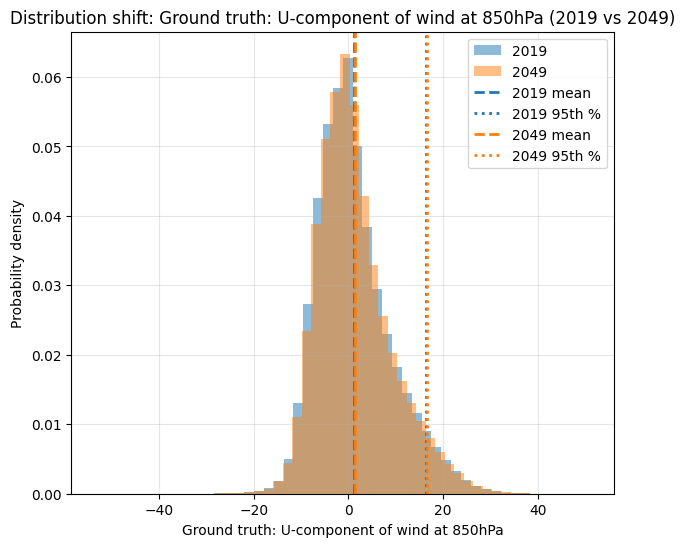

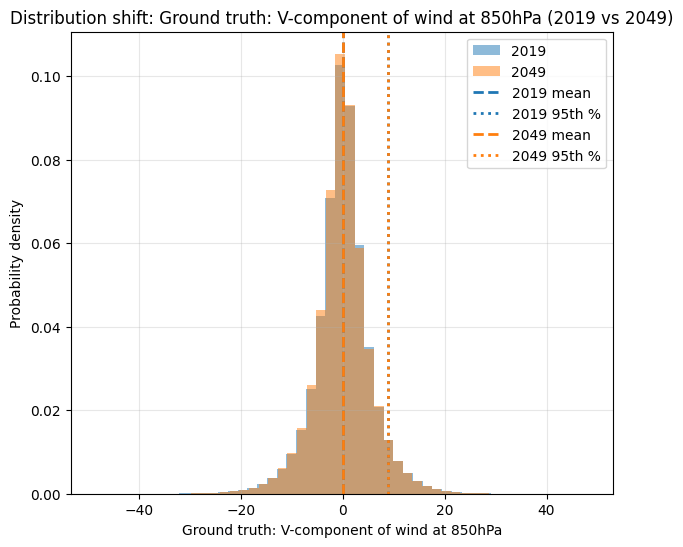

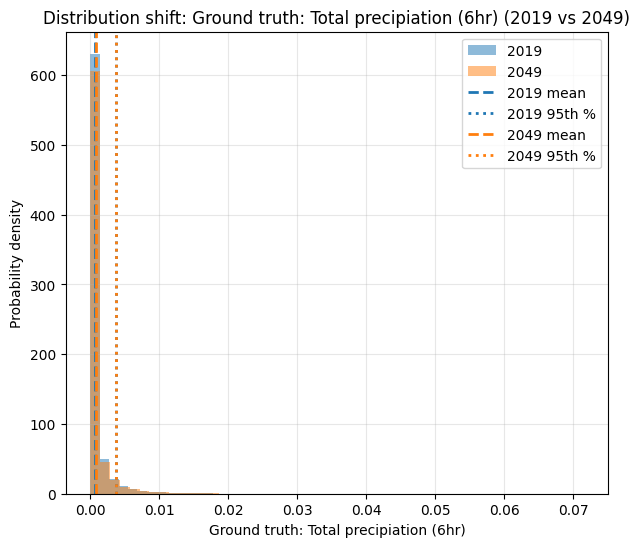

In [15]:
# Zonally weighted
for i, (display_name, unit, variable, plevel) in enumerate(plot.KEY_VARIABLES):
    plot_distributions(all_truth_201819[i], all_truth_2049[i], variable_name='Ground truth: '+ display_name, save_to=base_save_folder + f'truth_distribution_shift/{display_name.replace(" ", "_")}_zonally_weighted.png')

In [16]:
for i, (display_name, unit, variable, plevel) in enumerate(plot.KEY_VARIABLES):
    plevel_display = f' at {plevel}hPa' if plevel else ' at surface'
    plot.plot_zonal_plot(
        all_mean_truth_difference[i],
        title=f"Absolute difference in {display_name} (2049 vs 2019)",
        y_label=f"Absolute difference (2049 / 2019) in {unit}",
        #vbounds=(-max_val,max_val),
        base_save_folder=base_save_folder+"zonal_average_shift/",
        save_name=f"zonal_truth_difference_{variable}{plevel_display.replace(' ', '_')}",
        label_below="Value decrease (in 2049)",
        label_above="Value increase (in 2049)",
        centered_around=0,
        color_above='green',
        color_below='red'
    )

In [17]:
for i, (display_name, unit, variable, plevel) in enumerate(plot.KEY_VARIABLES):
    plevel_display = f' at {plevel}hPa' if plevel else ' at surface'
    plot.plot_zonal_plot(
        all_relative_performance_percentage[i],
        title=f"Zonal mean of relative performance error after {error_after_x_steps} steps (2049 vs 2019)\n{display_name}",
        y_label="Relative RMSE (2049 - 2019) / 2019 in %",
        centered_around=0,
        base_save_folder=base_save_folder+"zonal_relative_performance/",
        save_name=f"zonal_relative_performance_percentage_{variable}{plevel_display.replace(' ', '_')}_after{error_after_x_steps}steps"
    )


In [27]:
plt.figure(figsize=(7,6))
plt.scatter(weighted_wasserstein, weighted_rmse_list)
for i, (display_name, unit, variable, plevel) in enumerate(plot.KEY_VARIABLES):
    plevel_display = f' at {plevel}hPa' if plevel else ' at surface'
    # Annotate each variable
    plt.text(weighted_wasserstein[i]*1.01, weighted_rmse_list[i]*1.01, display_name)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Wasserstein distance (normalized, area-weighted)")
plt.xlim(0, max(weighted_wasserstein) * 1.7)
plt.ylabel("Performance degradation (%)")
plt.title("Model robustness: 2049 vs 2019 (weighted)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(base_save_folder+"relative_performance_degradation_per_normalized_wasserstein_distance_.png", dpi=300)
plt.close()

### Local RMSE per Wasserstein distance

Computing the Wasserstein distance between the distribution per gridpoint over 2049 and the global distribution in 2049.
Plot the local RMSE per grid point after x steps onto the local Wasserstein distance.

In [19]:
index = 1

gt = all_truth_2049[index].astype(np.float32).load()  # (time, lon, lat)
sim_sel = all_forecast_2049[index].astype(np.float32).load()   # (time, lon, lat)
relative_rmse_difference = (all_performance_2049[index]-all_performance_1819[index])/all_performance_1819[index]
true_data_mean = all_truth_2049[index].mean(dim='time')
true_data_mean_19 = all_truth_201819[index].mean(dim='time') 

display_name, unit, variable, plevel = plot.KEY_VARIABLES[index]
plevel_display = f' at {plevel}hPa' if plevel else ' at surface'

In [12]:
from joblib import Parallel, delayed
import numpy as np
import xarray as xr
from tqdm import tqdm

gt_vals = gt.values
sim_vals = sim_sel.values

# --- Latitude weights ---
lats = gt["latitude"].values
w_lat = np.cos(np.deg2rad(lats))
w_lat = w_lat / w_lat.mean()

# Broadcast weights to (time, lon, lat)
W = xr.DataArray(
    np.broadcast_to(w_lat[np.newaxis, np.newaxis, :],
                    gt.shape),
    coords=gt.coords, dims=gt.dims
)

# Precompute flattened global distribution
vals_global = gt_vals.flatten()
wg_global   = W.values.flatten()

mask_global = np.isfinite(vals_global)
vals_global = vals_global[mask_global]
wg_global   = wg_global[mask_global]

# Convert coords to plain floats (important for joblib!)
lons = gt.longitude.values.astype(float)
lats = gt.latitude.values.astype(float)
points = [(lon, lat) for lon in lons for lat in lats]
lon_index = {lon: i for i, lon in enumerate(gt.longitude.values)}
lat_index = {lat: j for j, lat in enumerate(gt.latitude.values)}

some_local_gt = gt_vals[:, 0, 0]
w_local = np.ones_like(some_local_gt)

def process_point(lon, lat):
    # Extract raw NumPy arrays (avoids slow .sel each call)
    i, j = lon_index[lon], lat_index[lat]
    local_gt = gt_vals[:, i, j]    
    local_sim = sim_vals[:, i, j]  

    ws = float(weighted_wasserstein_1d(local_gt, vals_global, w_local, wg_global))
    rmse = float(np.sqrt(np.mean((local_sim - local_gt) ** 2)))
    return ws, rmse

# Parallel loop
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(process_point)(lon, lat) for lon, lat in tqdm(points)
)

# Convert results directly to arrays for plotting
results = np.array(results)   # shape (npoints, 2)
ws_distances = results[:, 0]
rmses = results[:, 1]


100%|██████████| 8192/8192 [07:55<00:00, 17.22it/s]


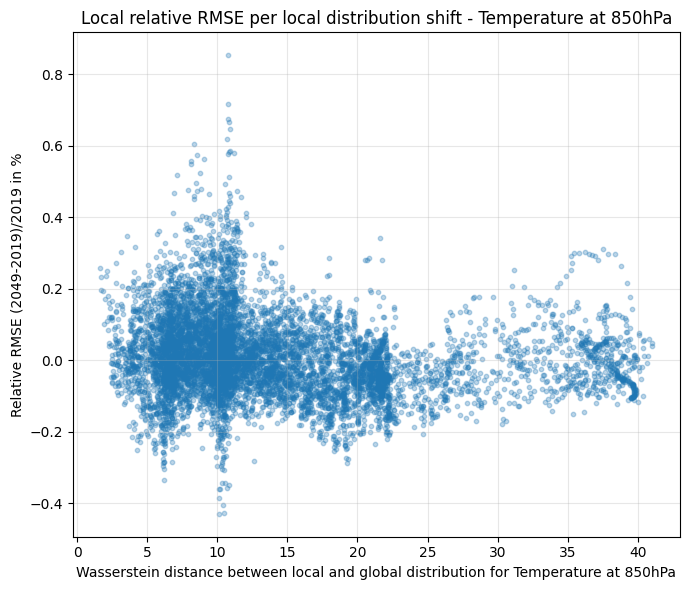

In [13]:
plt.figure(figsize=(7,6))
plt.scatter(ws_distances, relative_rmse_difference, alpha=0.3, s=10)
plt.xlabel(f"Wasserstein distance between local and global distribution for {display_name}")
plt.ylabel("Relative RMSE (2049-2019)/2019 in %")
plt.title(f"Local relative RMSE per local distribution shift - {display_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(base_save_folder+variable+f"/rel_rmse_per_local_to_global_wasserstein_point_{variable}{plevel_display.replace(' ', '_')}.png", dpi=300)

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from importlib import reload
reload(plot)
import plot_utils as plot 

# Get lon/lat coordinates
lons = gt.longitude.values
lats = gt.latitude.values

# Reshape 1D arrays into 2D grids
n_lon = len(lons)
n_lat = len(lats)

ws_grid = np.reshape(ws_distances, (n_lon, n_lat))   
rmse_grid = np.reshape(rmses, (n_lon, n_lat))       

ws_ds = xr.Dataset(
            {variable: (('longitude','latitude'), ws_grid)},
            coords={
        "latitude": lats,
        "longitude": lons,
    })

# Optional: flip latitude if needed for plotting
if lats[0] > lats[-1]:
    ws_grid = ws_grid[::-1, :]
    rmse_grid = rmse_grid[::-1, :]
    lats = lats[::-1]

plot.plot_double_plot(data_left=ws_ds[variable].T,
                 title_left=f"Distribution shift (Wasserstein, 2049 local to global)\n{display_name}",
                 cbar_label_left="Distribution shift",
                 vbounds_left=None,
                 cmap_left="Reds",
                 data_right=true_data_mean.T,
                 title_right=f"Yearly average (2049)\n{display_name}",
                 cbar_label_right=unit,
                 vbounds_right=None,
                 cmap_right="coolwarm",
                 base_save_folder=base_save_folder,
                 save_name=variable+f"/local_to_global_wasserstein_and_yearly_average_{variable}{plevel_display.replace(' ', '_')}")

                
# plot_map(all_truth_2049[0].mean(dim='time'), lons, lats, title="Ground truth 49")
plot.plot_single_plot(data_left=relative_rmse_difference.T,
                 title_left=f"Relative RMSE difference (2049-2019)/2019 after {error_after_x_steps} steps",
                 cbar_label_left="Relative RMSE difference in %",
                 vbounds_left=None,
                 cmap_left="coolwarm",
                 base_save_folder=base_save_folder,
                 save_name=variable+f"/relative_rmse_2049_to_2019_after_{error_after_x_steps}steps_{variable}{plevel_display.replace(' ', '_')}")
plot.plot_single_plot(data_left=(true_data_mean - true_data_mean_19).T,
                 title_left=f"Mean value difference (2049-2019)",
                 cbar_label_left=f"Mean difference in {unit}",
                 vbounds_left=None,
                 cmap_left="coolwarm",
                 base_save_folder=base_save_folder,
                 save_name=variable+f"/mean_value_difference_2049_to_2019_{variable}{plevel_display.replace(' ', '_')}")


NameError: name 'ws_distances' is not defined

In [ ]:
lats = truth_hist['latitude'].values
w_lat = np.cos(np.deg2rad(lats))
print(w_lat)

[6.12323400e-17 4.98458857e-02 9.95678466e-02 1.49042266e-01
 1.98146143e-01 2.46757398e-01 2.94755174e-01 3.42020143e-01
 3.88434796e-01 4.33883739e-01 4.78253979e-01 5.21435203e-01
 5.63320058e-01 6.03804410e-01 6.42787610e-01 6.80172738e-01
 7.15866849e-01 7.49781203e-01 7.81831482e-01 8.11938006e-01
 8.40025923e-01 8.66025404e-01 8.89871809e-01 9.11505852e-01
 9.30873749e-01 9.47927346e-01 9.62624247e-01 9.74927912e-01
 9.84807753e-01 9.92239207e-01 9.97203797e-01 9.99689182e-01
 9.99689182e-01 9.97203797e-01 9.92239207e-01 9.84807753e-01
 9.74927912e-01 9.62624247e-01 9.47927346e-01 9.30873749e-01
 9.11505852e-01 8.89871809e-01 8.66025404e-01 8.40025923e-01
 8.11938006e-01 7.81831482e-01 7.49781203e-01 7.15866849e-01
 6.80172738e-01 6.42787610e-01 6.03804410e-01 5.63320058e-01
 5.21435203e-01 4.78253979e-01 4.33883739e-01 3.88434796e-01
 3.42020143e-01 2.94755174e-01 2.46757398e-01 1.98146143e-01
 1.49042266e-01 9.95678466e-02 4.98458857e-02 6.12323400e-17]


In [22]:
print(all_relative_performance_percentage)

[<xarray.DataArray 'geopotential' (longitude: 128, latitude: 64)> Size: 66kB
dask.array<mul, shape=(128, 64), dtype=float64, chunksize=(128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude              (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
    level                 int64 8B 500
  * longitude             (longitude) float64 1kB 0.0 2.812 ... 354.4 357.2
    prediction_timedelta  timedelta64[ns] 8B 00:00:00.000000120, <xarray.DataArray 'temperature' (longitude: 128, latitude: 64)> Size: 66kB
dask.array<mul, shape=(128, 64), dtype=float64, chunksize=(128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude              (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
    level                 int64 8B 850
  * longitude             (longitude) float64 1kB 0.0 2.812 ... 354.4 357.2
    prediction_timedelta  timedelta64[ns] 8B 00:00:00.000000120, <xarray.DataArray 'specific_humidity' (longitude: 128, latitude: 64)> Size: 66kB
dask.array<mul, shape=(128, 64), dtyp

In [23]:
calculated_rmse = [(x.mean(dim="longitude") * w_lat).sum() / w_lat.sum() for x in all_relative_performance_percentage]

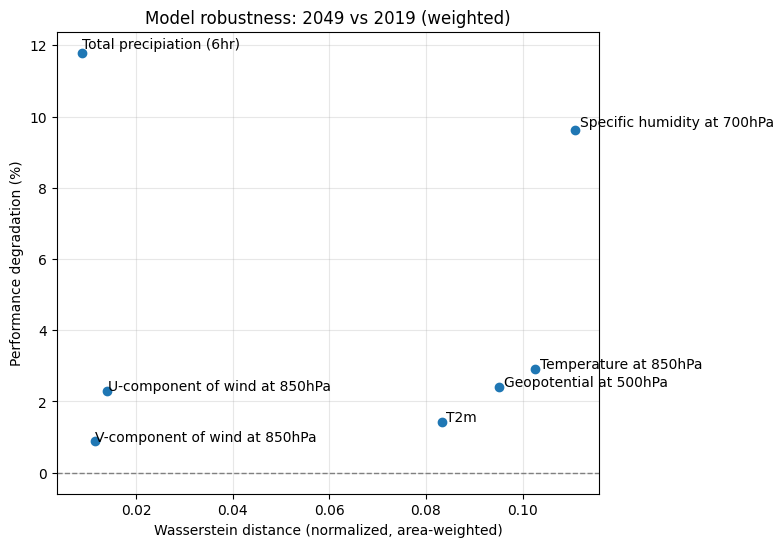

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(weighted_wasserstein, calculated_rmse)
for i, (display_name, unit, variable, plevel) in enumerate(plot.KEY_VARIABLES):
    plevel_display = f' at {plevel}hPa' if plevel else ' at surface'
    # Annotate each variable
    plt.text(weighted_wasserstein[i]*1.01, calculated_rmse[i]*1.01, display_name)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Wasserstein distance (normalized, area-weighted)")
plt.xlim(max(weighted_wasserstein)*1.7)
plt.ylabel("Performance degradation (%)")
plt.title("Model robustness: 2049 vs 2019 (weighted)")
plt.grid(True, alpha=0.3)
plt.savefig(base_save_folder+"relative_performance_degradation_per_normalized_wasserstein_distance.png", dpi=300)

In [9]:

plot.plot_double_plot(data_left=shift_map_2049.T,
                 title_left=f"Distribution shift (Wasserstein, 2049 vs 2019)\n{variable}{f' at {plevel}hPa' if plevel else ''}",
                 cbar_label_left="Distribution shift",
                 vbounds_left=None,
                 cmap_left="Reds",
                 data_right=relative_performance_error.T,
                 title_right=f"Relative performance degradation (RMSE 2049 / 2019)\n{variable}{f' at {plevel}hPa' if plevel else ''}",
                 cbar_label_right="Relative performance degradation",
                 vbounds_right=(0.3, 1.7),
                 cmap_right="coolwarm",
                 base_save_folder=base_save_folder,
                 save_name=f'shift_relative_performance_{info_to_save}')

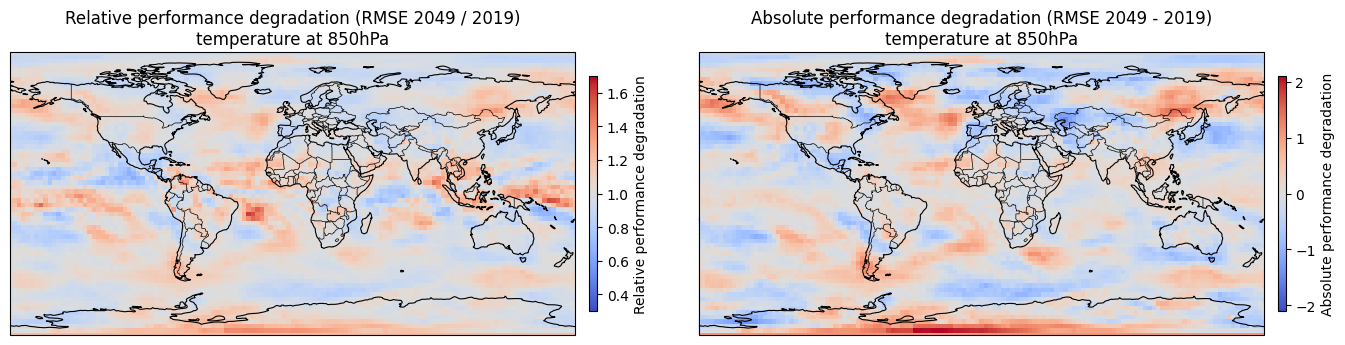

In [ ]:

plot.plot_double_plot(data_left=relative_performance_error.T,
                 title_left=f"Relative performance degradation (RMSE 2049 / 2019)\n{variable}{f' at {plevel}hPa' if plevel else ''}",
                 cbar_label_left="Relative performance degradation",
                 vbounds_left=(0.3, 1.7),
                 cmap_left="coolwarm",
                 data_right=absolute_performance_error.T,
                 title_right=f"Absolute performance degradation (RMSE 2049 - 2019)\n{variable}{f' at {plevel}hPa' if plevel else ''}",
                 cbar_label_right="Absolute performance degradation",
                 vbounds_right=None,
                 cmap_right="coolwarm",
                 base_save_folder=base_save_folder,
                 save_name=f"absolute_relative_performance_{info_to_save}")

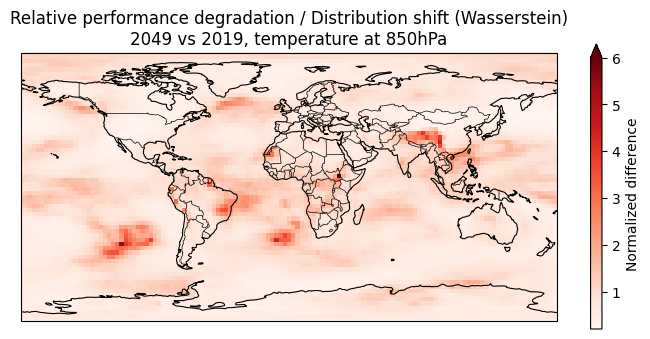

In [62]:
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 1, figsize=(7,6), subplot_kw={"projection": proj})
(relative_performance_error / shift_map_2049).T.plot(ax=axes, cmap="Reds", transform=proj, vmax=6, cbar_kwargs={"shrink": 0.5, "aspect": 25, "label": "Normalized difference"})
axes.add_feature(cfeature.COASTLINE, linewidth=0.8)
axes.add_feature(cfeature.BORDERS, linewidth=0.5)
axes.set_title(f"Relative performance degradation / Distribution shift (Wasserstein)\n2049 vs 2019, {variable}{f' at {plevel}hPa' if plevel else ''}")

plt.tight_layout()
plt.savefig(base_save_folder+f"normalized_performance_degradation_{info_to_save}.png", dpi=300, bbox_inches='tight')